# Hospital Readmission Prediction

In [ ]:
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading and Exploration

In [ ]:
import os

DATA_PATH = "diabetic_data.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Shape:", df.shape)
display(df.dtypes)
print("\nMissing values per column:")
display(df.isna().sum())

display(df.describe(include="all").T)

Shape: (101766, 50)


,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



Missing values per column:


,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983458,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [ ]:
import pandas as pd

# Load and display the IDS mapping file
ids_mapping = pd.read_csv('/content/IDS_mapping.csv')
display(ids_mapping.head(30))

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


In [ ]:
TARGET = 'readmitted'
DROP_COLS = [
    "encounter_id",       # metadata
    "patient_nbr",        # identifier
    "weight",             # >96% missing
    "payer_code",         # >40% missing
    "medical_specialty",  # high missingness + many rare categories
]
CAT_COL = [
    "race", "gender", "age",
    "admission_type_id", "discharge_disposition_id", "admission_source_id",
    "diag_1", "diag_2", "diag_3",
    "max_glu_serum", "A1Cresult",
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone", "change", "diabetesMed",
]
DRUG_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone",
]
NUM_COLS = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
    "number_inpatient",
    "number_outpatient",
    "number_emergency",
]
ID_AS_CAT = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
VISIT_COLS = ["number_inpatient", "number_outpatient", "number_emergency"]

In [ ]:
def clean_df(df: pd.DataFrame,
             drop_cols=DROP_COLS,
             id_as_cat=ID_AS_CAT,
             missing_token="?") -> pd.DataFrame:
    """
    Cleaning:
    - Replace '?' with NaN
    - Drop ID/high-missing/high-cardinality columns
    - Cast id-coded categorical ints to string
    - Remove rows that cannot be readmitted (hospice, deaths)
    - Remove newborn admissions (irrelevant to readmission)
    - Keep first encounter per patient only
    """
    X = df.copy()

    # 1. Normalize missing markers
    X = X.replace(missing_token, np.nan)

    # 2. Drop specified columns
    X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

    # 3. Row-level filters
    if "discharge_disposition_id" in X.columns:
        X["discharge_disposition_id"] = pd.to_numeric(
            X["discharge_disposition_id"], errors="coerce"
        )
        EXCLUDE_DISPOSITIONS = [11, 13, 14, 19, 20, 21]
        X = X[~X["discharge_disposition_id"].isin(EXCLUDE_DISPOSITIONS)]

    if "admission_type_id" in X.columns:
        X["admission_type_id"] = pd.to_numeric(
            X["admission_type_id"], errors="coerce"
        )
        X = X[~X["admission_type_id"].isin([4])]

    if "patient_nbr" in X.columns:
        X = X.drop_duplicates(subset="patient_nbr", keep="first")

    # 4. Cast ID-coded categoricals to string
    for c in id_as_cat:
        if c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce").astype("Int64").astype("string")

    return X

In [ ]:
# Clean
df_clean = clean_df(df)

# Right after clean_df(), before encoding — save original for EDA
df_eda = df_clean.copy()  # still has "<30", ">30", "NO" strings

# Then encode
df_clean["readmitted"] = df_clean["readmitted"].map({"<30": 1, ">30": 0, "NO": 0})

In [ ]:
# Discharge IDs 11, 13, 14, 19, 20, 21 represent Hospice or Death
expired_ids = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df['discharge_disposition_id'].isin(expired_ids)].copy()

/tmp/ipykernel_1546/1034177082.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[~df['discharge_disposition_id'].isin(expired_ids)].copy()


In [ ]:
import pandas as pd
import numpy as np

def _icd_to_group(code) -> str:
    """
    Refined ICD-9 grouping specifically for Diabetes Readmission.
    Isolates 250.xx (Diabetes) and common comorbidities.
    """
    if pd.isna(code):
        return "missing"

    c = str(code).strip().upper()
    if c == "" or c in {"NAN", "NONE", "?"}:
        return "missing"

    if c.startswith("V"):
        return "supplementary_V"
    if c.startswith("E"):
        return "external_E"

    # Numeric extraction
    num_part = ""
    for ch in c:
        if ch.isdigit() or ch == ".":
            num_part += ch
        else:
            break

    try:
        val = float(num_part)
    except ValueError:
        return "other"

    # --- CLINICAL GROUPING ---
    # Isolate Diabetes (The core feature)
    if 250 <= val < 251:
        return "diabetes"

    # Standard ICD-9 Chapters
    if 1 <= val < 140:    return "infectious"
    if 140 <= val < 240:  return "neoplasms"
    if 240 <= val < 280:  return "endocrine_other" # Non-diabetes endocrine
    if 280 <= val < 290:  return "blood"
    if 290 <= val < 320:  return "mental"
    if 320 <= val < 390:  return "nervous"
    if 390 <= val < 460:  return "circulatory"
    if 460 <= val < 520:  return "respiratory"
    if 520 <= val < 580:  return "digestive"
    if 580 <= val < 630:  return "genitourinary"
    if 630 <= val < 680:  return "pregnancy"
    if 680 <= val < 710:  return "skin"
    if 710 <= val < 740:  return "musculoskeletal"
    if 740 <= val < 800:  return "symptoms_congenital" # Grouping rare/vague codes
    if 800 <= val < 1000: return "injury"

    return "other"

# Data visualization

Frequencies of classes:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64 

Ratio of classes:
 readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: count, dtype: float64


<Axes: title={'center': 'Distribution of classes'}, xlabel='readmitted', ylabel='# of Transactions'>

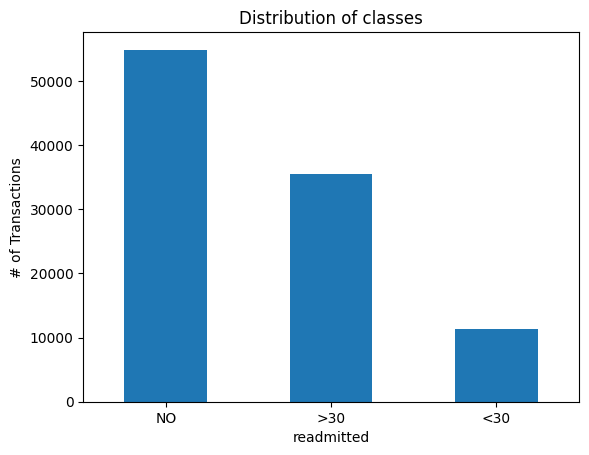

In [ ]:
# Distribution of readmission
cat_dist = df["readmitted"].value_counts()
print("Frequencies of classes:\n", cat_dist, "\n")

# Ratio of classes
print("Ratio of classes:\n", cat_dist/len(df))

# Plot the distribution of classes
plt.xlabel("Class")
plt.ylabel("# of Transactions")
cat_dist.plot(kind="bar", title="Distribution of classes", rot=0)

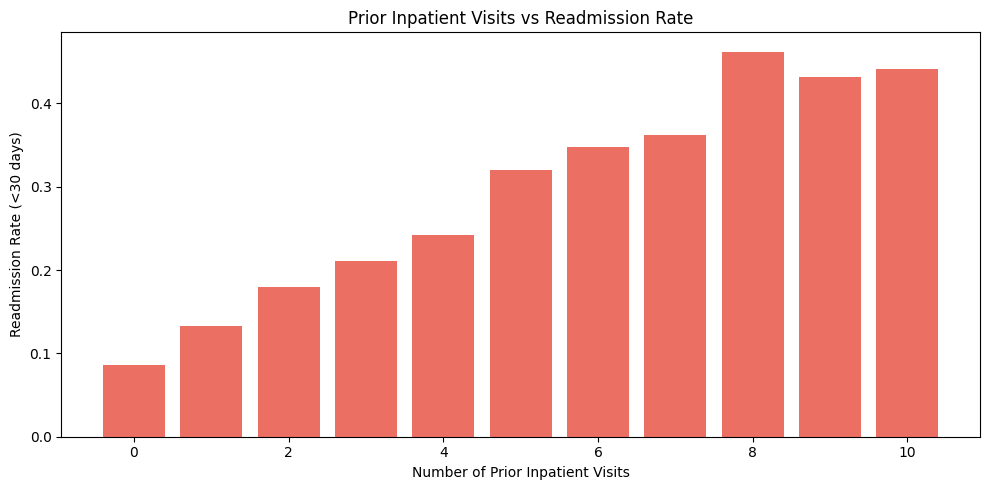

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

readmit_by_inpatient = (
    df_eda.groupby("number_inpatient")["readmitted"]
    .apply(lambda x: (x == "<30").mean())
    .reset_index()
    .rename(columns={"readmitted": "readmit_rate"})
    .query("number_inpatient <= 10")
)

ax.bar(readmit_by_inpatient["number_inpatient"],
       readmit_by_inpatient["readmit_rate"],
       color="#e74c3c", alpha=0.8)
ax.set_xlabel("Number of Prior Inpatient Visits")
ax.set_ylabel("Readmission Rate (<30 days)")
ax.set_title("Prior Inpatient Visits vs Readmission Rate")
plt.tight_layout()
plt.show()

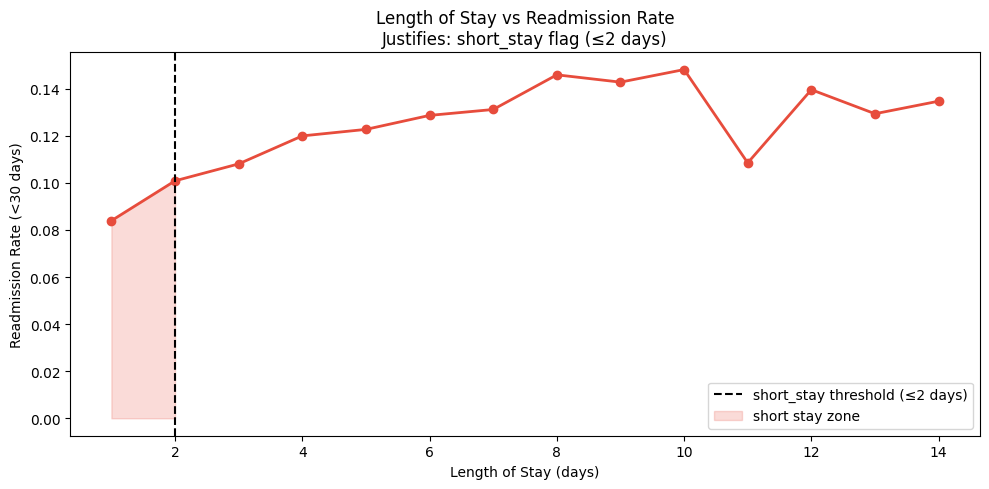

In [ ]:
readmit_by_los = (
    df_eda.groupby("time_in_hospital")["readmitted"]
    .apply(lambda x: (x == "<30").mean())
    .reset_index()
    .rename(columns={"readmitted": "readmit_rate"})
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(readmit_by_los["time_in_hospital"],
        readmit_by_los["readmit_rate"],
        marker="o", color="#e74c3c", linewidth=2)
ax.axvline(x=2, color="black", linestyle="--", label="short_stay threshold (≤2 days)")
ax.fill_between(readmit_by_los["time_in_hospital"],
                readmit_by_los["readmit_rate"],
                where=readmit_by_los["time_in_hospital"] <= 2,
                alpha=0.2, color="#e74c3c", label="short stay zone")
ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Readmission Rate (<30 days)")
ax.set_title("Length of Stay vs Readmission Rate\nJustifies: short_stay flag (≤2 days)")
ax.legend()
plt.tight_layout()
plt.show()

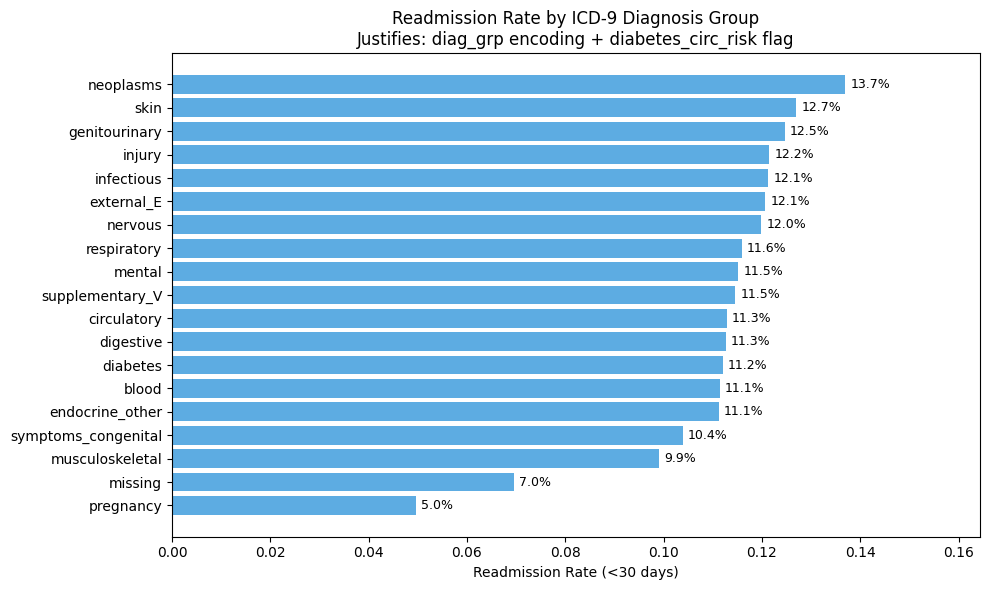

In [ ]:
diag_readmit = []
for col in ["diag_1", "diag_2", "diag_3"]:
    temp = df_eda.copy()
    temp["diag_grp"] = temp[col].map(lambda x: _icd_to_group(x) or "other")
    temp["is_readmit"] = (temp["readmitted"] == "<30").astype(int)
    # ← use df_clean["readmitted"] which still has string values
    diag_readmit.append(temp[["diag_grp", "is_readmit"]])

diag_df = pd.concat(diag_readmit)
diag_rates = (
    diag_df.groupby("diag_grp")["is_readmit"]
    .agg(["mean", "count"])
    .query("count > 500")
    .sort_values("mean", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(diag_rates["diag_grp"], diag_rates["mean"],
               color="#3498db", alpha=0.8)

# Fix: format as percentage string manually
for bar, val in zip(bars, diag_rates["mean"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", ha="left", fontsize=9)

ax.set_xlim(0, diag_rates["mean"].max() * 1.2)  # make room for labels
ax.set_xlabel("Readmission Rate (<30 days)")
ax.set_title("Readmission Rate by ICD-9 Diagnosis Group\n"
             "Justifies: diag_grp encoding + diabetes_circ_risk flag")
plt.tight_layout()
plt.show()

In [ ]:
# Check readmission rate for diabetes + circulatory COMBINATION
has_diabetes = df_eda[["diag_1", "diag_2", "diag_3"]].apply(
    lambda col: col.map(lambda x: _icd_to_group(x) or "other")
).eq("diabetes").any(axis=1)

has_circulatory = df_eda[["diag_1", "diag_2", "diag_3"]].apply(
    lambda col: col.map(lambda x: _icd_to_group(x) or "other")
).eq("circulatory").any(axis=1)

has_neoplasm = df_eda[["diag_1", "diag_2", "diag_3"]].apply(
    lambda col: col.map(lambda x: _icd_to_group(x) or "other")
).eq("neoplasms").any(axis=1)

combos = {
    "diabetes + circulatory": (has_diabetes & has_circulatory),
    "diabetes only":           (has_diabetes & ~has_circulatory),
    "circulatory only":        (~has_diabetes & has_circulatory),
    "neoplasms":                has_neoplasm,
}

print(f"{'Group':<30} {'Readmit Rate':>12} {'Count':>8}")
print("-" * 52)
for name, mask in combos.items():
    rate  = (df_eda.loc[mask, "readmitted"] == "<30").mean()
    count = mask.sum()
    print(f"{name:<30} {rate:>12.1%} {count:>8,}")

Group                          Readmit Rate    Count
----------------------------------------------------
diabetes + circulatory                11.0%   18,025
diabetes only                         11.1%   19,635
circulatory only                      11.6%   39,244
neoplasms                             13.2%    5,601


Sample discharge_disposition_id values:
discharge_disposition_id
1     60228
3     13954
6     12898
18     3691
2      2128
22     1993
5      1184
25      989
4       815
7       623
Name: count, dtype: Int64

Rows in disp_readmit: 11
              disp_label  is_care      mean  count
0         Long Term Care     True  0.072816    412
1     Discharged to Home    False  0.093013  60228
2    Home Health Service     True  0.126919  12898
3                    ICF     True  0.127607    815
4       Home IV Provider     True  0.138889    108
5               Left AMA    False  0.144462    623
6                    SNF     True  0.146625  13954
7    Short-term Hospital    False  0.160714   2128
8   Other Inpatient Care     True  0.208615   1184
9         Rehab Facility     True  0.276969   1993
10  Psychiatric Hospital     True  0.366906    139


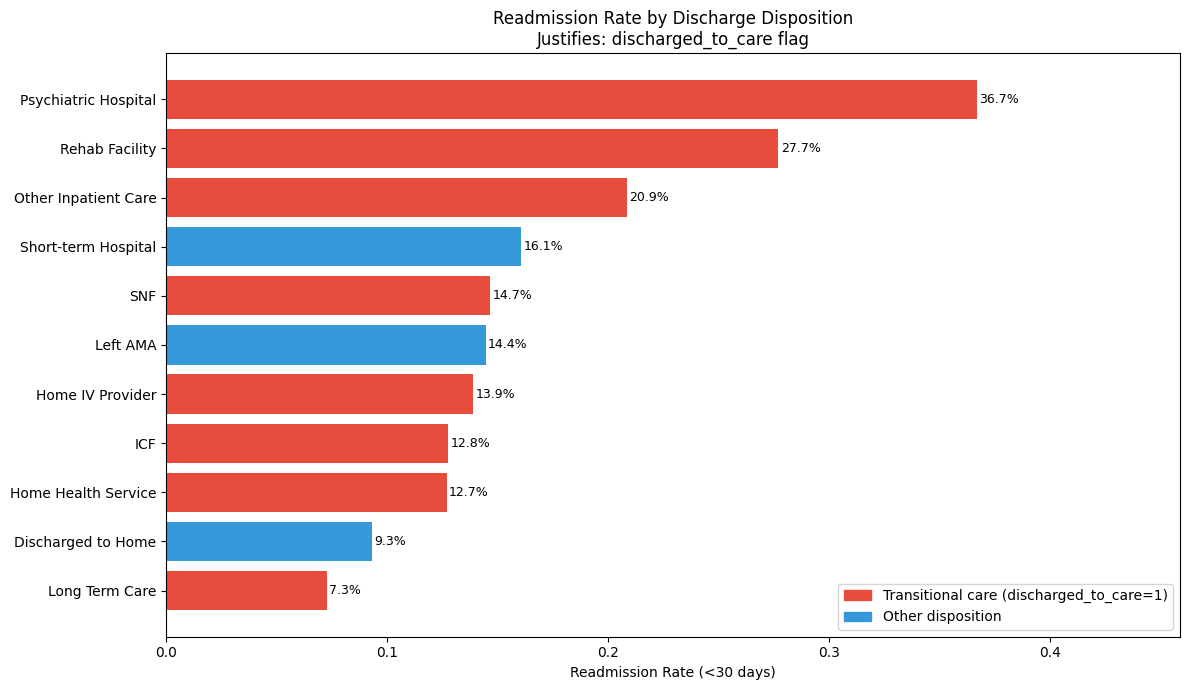

In [ ]:
from matplotlib.patches import Patch

CARE_DISPOSITIONS = [3, 4, 5, 6, 8, 9, 12, 15, 22, 23, 24, 27, 28]

disposition_label = {
    "1":  "Discharged to Home",
    "2":  "Short-term Hospital",
    "3":  "SNF",
    "4":  "ICF",
    "5":  "Other Inpatient Care",
    "6":  "Home Health Service",
    "7":  "Left AMA",
    "8":  "Home IV Provider",
    "9":  "Admitted as Inpatient",
    "12": "Still Patient",
    "15": "Medicare Swing Bed",
    "16": "Outpatient Services (other)",
    "17": "Outpatient Services (this)",
    "22": "Rehab Facility",
    "23": "Long Term Care",
    "24": "Nursing Facility (Medicaid)",
    "27": "Federal Health Care",
    "28": "Psychiatric Hospital",
    "29": "Critical Access Hospital",
    "30": "Other Health Care Institution",
}

care_str  = [str(x) for x in CARE_DISPOSITIONS]

# Debug
print("Sample discharge_disposition_id values:")
print(df_eda["discharge_disposition_id"].value_counts().head(10))

disp_readmit = (
    df_eda[df_eda["discharge_disposition_id"].isin(disposition_label.keys())]
    .assign(
        disp_label=lambda x: x["discharge_disposition_id"].map(disposition_label),
        is_care=lambda x: x["discharge_disposition_id"].isin(care_str),
        is_readmit=lambda x: (x["readmitted"] == "<30").astype(int)
    )
    .groupby(["disp_label", "is_care"])["is_readmit"]
    .agg(["mean", "count"])
    .query("count > 100")
    .sort_values("mean", ascending=True)
    .reset_index()
)

print(f"\nRows in disp_readmit: {len(disp_readmit)}")
print(disp_readmit)

assert len(disp_readmit) > 0, \
    "disp_readmit is empty — discharge_disposition_id dtype mismatch"

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#e74c3c" if care else "#3498db" for care in disp_readmit["is_care"]]
bars = ax.barh(disp_readmit["disp_label"], disp_readmit["mean"], color=colors)

for bar, val in zip(bars, disp_readmit["mean"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", ha="left", fontsize=9)

ax.set_xlim(0, disp_readmit["mean"].max() * 1.25)
ax.legend(handles=[
    Patch(color="#e74c3c", label="Transitional care (discharged_to_care=1)"),
    Patch(color="#3498db", label="Other disposition")
])
ax.set_xlabel("Readmission Rate (<30 days)")
ax.set_title("Readmission Rate by Discharge Disposition\n"
             "Justifies: discharged_to_care flag")
plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
def feature_engineer(df: pd.DataFrame,
                     visit_cols=['number_outpatient', 'number_emergency', 'number_inpatient'],
                     drug_cols=None,
                     drop_raw_diag=True,
                     drop_individual_drugs=True,
                     target_early_readmission=True) -> pd.DataFrame:
    """
    Feature Engineering for Hospital Readmission (<30 days)
    --------------------------------------------------------
    1. Weighted Clinical Intensity
    2. Diagnosis ICD-9 Grouping
    3. Comorbidity Flags
    4. Medication & Stability Features
    5. Service Density
    6. Early Readmission Specific Features
    7. Admission Type Encoding
    8. Age Ordinal Encoding
    9. Drop raw ID cols
    """
    X = df.copy()

    # ------------------------------------------------------------------
    # 1. Weighted Clinical Intensity
    # ------------------------------------------------------------------
    if all(c in X.columns for c in visit_cols):
        for c in visit_cols:
            X[c] = pd.to_numeric(X[c], errors="coerce").fillna(0)

        if all(c in X.columns for c in ["number_inpatient", "number_emergency", "number_outpatient"]):
            X["weighted_intensity"] = (
                (X["number_inpatient"]  * 3) +
                (X["number_emergency"]  * 2) +
                (X["number_outpatient"] * 1)
            )
            X["has_prior_visits"] = (X["weighted_intensity"] > 0).astype(int)

        X["total_visits"] = X[visit_cols].sum(axis=1)

    # ------------------------------------------------------------------
    # 2. Diagnosis Grouping (ICD-9 → clinical group)
    # ------------------------------------------------------------------
    diag_cols = ["diag_1", "diag_2", "diag_3"]
    for c in diag_cols:
        if c in X.columns:
            X[c + "_grp"] = (
                X[c].map(lambda x: _icd_to_group(x) or "other")
                    .astype(pd.StringDtype())
            )

    # ------------------------------------------------------------------
    # 3. Comorbidity Flags
    # ------------------------------------------------------------------
    grp_cols = [c + "_grp" for c in diag_cols if c + "_grp" in X.columns]
    if grp_cols:
        MEANINGFUL_GROUPS = {"diabetes", "circulatory", "respiratory", "metabolic"}

        X["comorbidity_count"] = (
            X[grp_cols]
            .apply(lambda row: len(set(row.dropna()) & MEANINGFUL_GROUPS), axis=1)
        )

        has_diabetes    = X[grp_cols].eq("diabetes").any(axis=1)
        has_circulatory = X[grp_cols].eq("circulatory").any(axis=1)
        has_neoplasm    = X[grp_cols].eq("neoplasms").any(axis=1)

        # Keep for volume justification — 18K patients
        X["diabetes_circ_risk"] = (has_diabetes & has_circulatory).astype(int)

        # Add neoplasm flag — highest readmit rate in EDA (13.2%)
        X["neoplasm_risk"] = has_neoplasm.astype(int)

    # ------------------------------------------------------------------
    # 4. Medication & Stability Features
    # ------------------------------------------------------------------
    if drug_cols is not None:
        present_drugs = [c for c in drug_cols if c in X.columns]

        if not present_drugs:
            warnings.warn("drug_cols provided but none found in DataFrame.")

        active = pd.DataFrame({
            c: (X[c].fillna("No").str.upper() != "NO").astype(int)
            for c in present_drugs
        })
        X["num_active_drugs"] = active.sum(axis=1)

        if "change" in X.columns:
            X["med_change_flag"] = (
                X["change"].fillna("No").str.upper() == "CH"
            ).astype(int)
            X = X.drop(columns=["change"], errors="ignore")

        if "diabetesMed" in X.columns:
            X["on_diabetes_med"] = (
                X["diabetesMed"].fillna("No").str.upper() == "YES"
            ).astype(int)
            X = X.drop(columns=["diabetesMed"], errors="ignore")

        if drop_individual_drugs:
            X = X.drop(columns=present_drugs, errors="ignore")

    else:
        warnings.warn("drug_cols not provided; skipping medication features.")

    # ------------------------------------------------------------------
    # 5. Service Density
    # ------------------------------------------------------------------
    if all(c in X.columns for c in ["num_lab_procedures", "time_in_hospital"]):
        X["num_lab_procedures"] = pd.to_numeric(X["num_lab_procedures"], errors="coerce").fillna(0)
        X["time_in_hospital"]   = pd.to_numeric(X["time_in_hospital"],   errors="coerce").fillna(1)
        X["lab_intensity"]      = X["num_lab_procedures"] / (X["time_in_hospital"] + 1)

    # ------------------------------------------------------------------
    # 6. Early Readmission (<30 day) Specific Features
    # ------------------------------------------------------------------
    if target_early_readmission:

        if "discharge_disposition_id" in X.columns:
            X["discharge_disposition_id"] = pd.to_numeric(
                X["discharge_disposition_id"], errors="coerce"
            )

            X["discharged_to_care"] = X["discharge_disposition_id"].isin(
                [str(x) for x in CARE_DISPOSITIONS]  # ← str because clean_df cast it
            ).astype(int)

        if "time_in_hospital" in X.columns:
            X["short_stay"] = (X["time_in_hospital"] <= 2).astype(int)

        if all(c in X.columns for c in ["num_procedures", "time_in_hospital"]):
            X["num_procedures"] = pd.to_numeric(X["num_procedures"], errors="coerce").fillna(0)
            X["procedures_per_day"] = X["num_procedures"] / (X["time_in_hospital"] + 1)

        if "admission_source_id" in X.columns:
            X["admission_source_id"] = pd.to_numeric(
                X["admission_source_id"], errors="coerce"
            )
            X["er_admission"] = X["admission_source_id"].isin([7]).astype(int)
            X = X.drop(columns=["admission_source_id"], errors="ignore")

        if all(c in X.columns for c in ["number_inpatient", "short_stay"]):
            X["inpatient_x_short_stay"] = X["number_inpatient"] * X["short_stay"]

        # Temp flag — used in block 7 to compute double_emergency
        X["_er_admission_temp"] = X.get("er_admission", pd.Series(0, index=X.index))

    # ------------------------------------------------------------------
    # 7. Admission Type Encoding
    # ------------------------------------------------------------------
    if "admission_type_id" in X.columns:
        X["admission_type_id"] = pd.to_numeric(X["admission_type_id"], errors="coerce")

        # Collapse junk/unknown codes to NaN
        X["admission_type_id"] = X["admission_type_id"].replace(
            {5: np.nan, 6: np.nan, 8: np.nan}
        )

        # Emergency admission type flag
        X["is_emergency_admission"] = X["admission_type_id"].isin([1, 7]).astype(int)

        # Double emergency: ER source AND emergency admission type
        if "_er_admission_temp" in X.columns:
            X["double_emergency"] = (
                X["_er_admission_temp"].astype(bool) &
                X["is_emergency_admission"].astype(bool)
            ).astype(int)
            X = X.drop(columns=["_er_admission_temp"], errors="ignore")

        # Inpatient x emergency interaction
        if "number_inpatient" in X.columns:
            X["inpatient_x_emergency"] = X["number_inpatient"] * X["is_emergency_admission"]

        # Map to meaningful labels
        X["admission_type"] = X["admission_type_id"].map({
            1: "emergency",
            2: "urgent",
            3: "elective",
            7: "trauma"
        })

        # One-hot encode
        X = pd.get_dummies(X, columns=["admission_type"], drop_first=False, dummy_na=True)

        # Drop redundant/low-signal dummies and raw ID
        X = X.drop(columns=[
            "admission_type_emergency",  # redundant with is_emergency_admission
            "admission_type_nan",        # unknown admissions, low signal
            "admission_type_id"          # raw ID fully replaced
        ], errors="ignore")

    # ------------------------------------------------------------------
    # 8. Age Ordinal Encoding
    # ------------------------------------------------------------------
    if "age" in X.columns:
        age_map = {
            "[0-10)":0,  "[10-20)":1, "[20-30)":2, "[30-40)":3, "[40-50)":4,
            "[50-60)":5, "[60-70)":6, "[70-80)":7, "[80-90)":8, "[90-100)":9
        }
        X["age"] = X["age"].map(age_map)

    # ------------------------------------------------------------------
    # 9. Drop raw ID cols — signal already extracted
    # ------------------------------------------------------------------
    X = X.drop(columns=[
        "discharge_disposition_id",  # → discharged_to_care
    ], errors="ignore")

    return X

In [ ]:
# 3. Engineer
y = df_clean["readmitted"]
X = df_clean.drop(columns=["readmitted", "patient_nbr", "encounter_id"], errors="ignore")
X = feature_engineer(X, drug_cols=DRUG_COLS, target_early_readmission=True)

# 4. Align
y = y.loc[X.index]
assert len(X) == len(y), f"Mismatch: X={len(X)}, y={len(y)}"

# 5. Column lists
num_cols  = X.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
bool_cols = X.select_dtypes(include="bool").columns.tolist()
cat_cols  = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols  = num_cols + bool_cols

# 6. Sanity checks
assert len(set(num_cols) & set(cat_cols)) == 0, "Overlap between num and cat cols!"
assert X.columns.duplicated().sum() == 0,       "Duplicate columns!"
assert "double_emergency" in num_cols,           "Key interaction feature missing!"
assert "admission_type_emergency" not in num_cols, "Redundant dummy still present!"

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Total: {len(num_cols) + len(cat_cols)}")

Numerical  (30): ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'weighted_intensity', 'has_prior_visits', 'total_visits', 'comorbidity_count', 'diabetes_circ_risk', 'neoplasm_risk', 'num_active_drugs', 'med_change_flag', 'on_diabetes_med', 'lab_intensity', 'discharged_to_care', 'short_stay', 'procedures_per_day', 'er_admission', 'inpatient_x_short_stay', 'is_emergency_admission', 'double_emergency', 'inpatient_x_emergency', 'admission_type_elective', 'admission_type_trauma', 'admission_type_urgent']
Categorical (10): ['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'diag_1_grp', 'diag_2_grp', 'diag_3_grp']
Total: 40


In [ ]:
print(y.value_counts())
print(y.dtype)
print(y.unique())

readmitted
0    88020
1    11313
Name: count, dtype: int64
int64
[0 1]


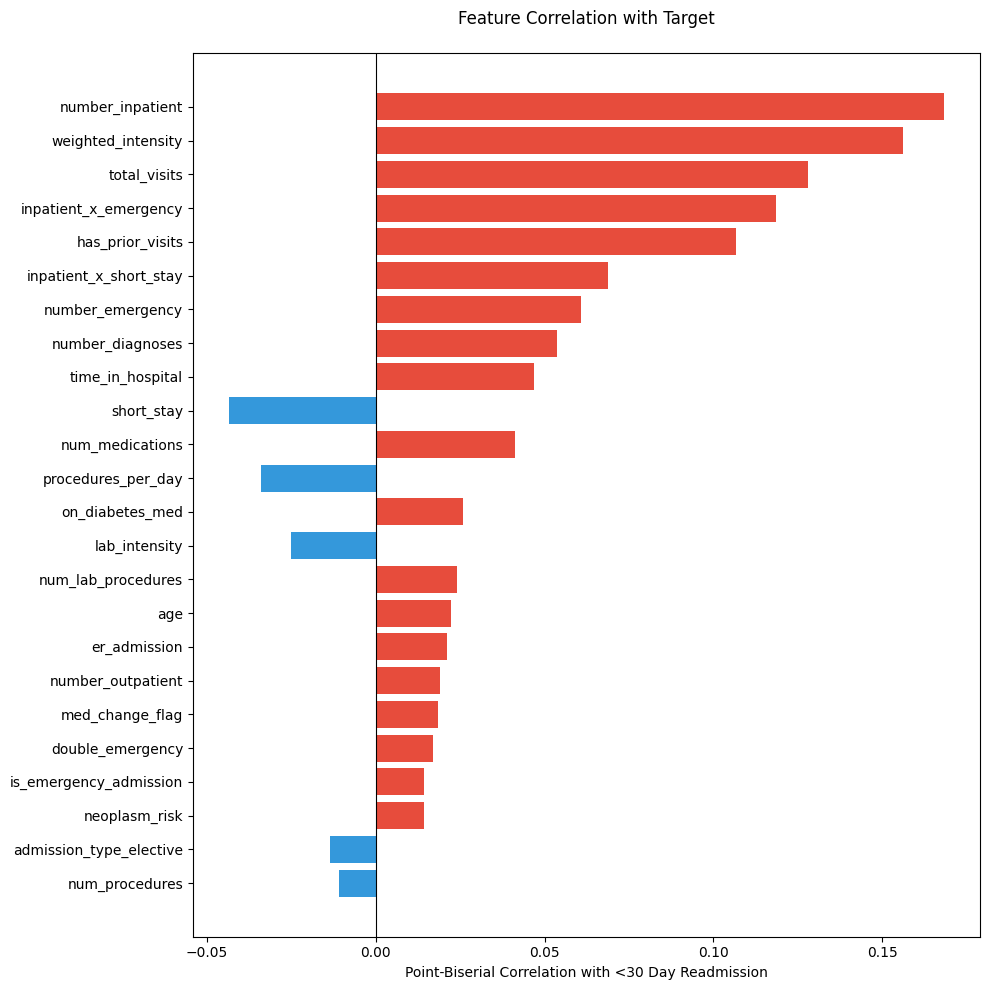

In [ ]:
# Compute point-biserial correlation of each numeric feature with target
from scipy import stats

correlations = {}
# Target is already encoded as 1 and 0
y_raw = df_clean["readmitted"]

for col in num_cols:
    if col in X.columns:
        valid = X[col].dropna().astype(float)
        y_valid = y_raw.loc[valid.index].astype(float)

        # Skip if either array is constant to avoid ConstantInputWarning
        if len(valid.unique()) > 1 and len(y_valid.unique()) > 1:
            corr, pval = stats.pointbiserialr(valid, y_valid)
            correlations[col] = {"correlation": corr, "pval": pval}

corr_df = (
    pd.DataFrame(correlations).T
    .dropna()
    .sort_values("correlation", key=abs, ascending=True)
    .query("pval < 0.05")  # only significant correlations
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in corr_df["correlation"]]
ax.barh(corr_df.index, corr_df["correlation"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Point-Biserial Correlation with <30 Day Readmission")
ax.set_title("Feature Correlation with Target\n")
plt.tight_layout()
plt.show()

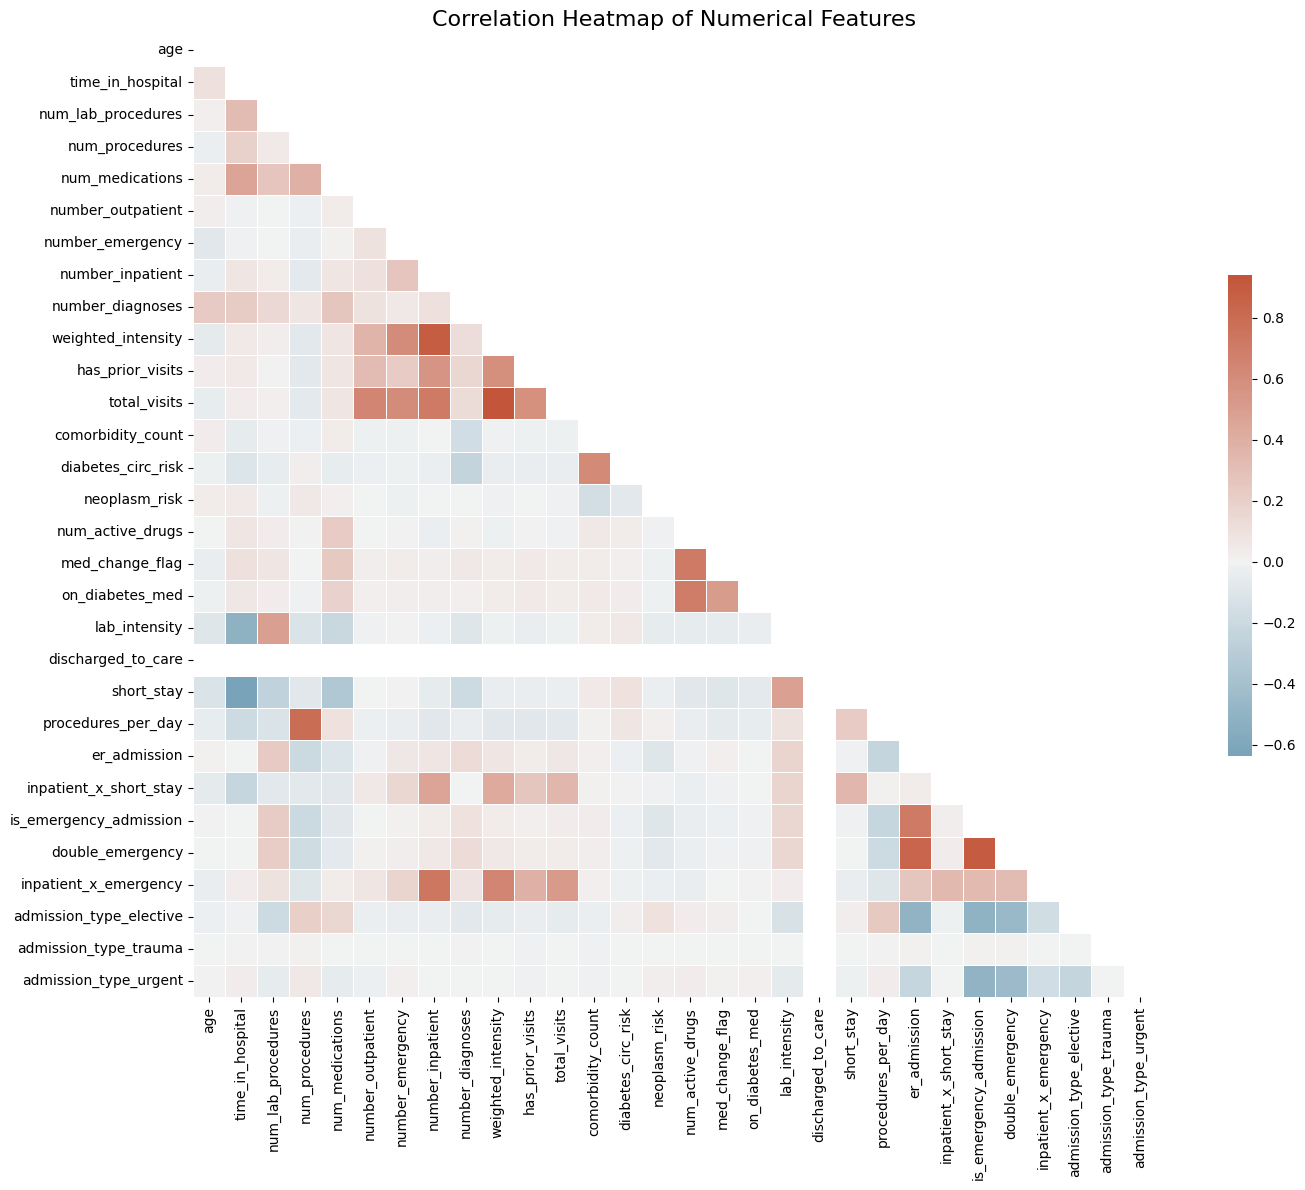

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation matrix for numerical features
corr_matrix = X[num_cols].corr()

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(16, 12))

# Generate a mask for the upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

ax.set_title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Train / Validation / Test Split

To avoid leakage, the test set is kept untouched until final evaluation.

We use:
- **Training set** for model fitting and hyperparameter tuning
- **Validation set** for threshold tuning and cost-sensitive operating-point selection
- **Test set** for one-time final evaluation only


In [ ]:
from sklearn.model_selection import train_test_split

# First split: untouched final test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: validation set from training portion
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,   # final: 64% train, 16% val, 20% test
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Train shape:     ", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:      ", X_test.shape)

print(f"Positive rate (train):      {y_train.mean():.4f}")
print(f"Positive rate (validation): {y_val.mean():.4f}")
print(f"Positive rate (test):       {y_test.mean():.4f}")

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"scale_pos_weight (train only): {scale_pos_weight_value:.2f}")



Train shape:      (63572, 40)
Validation shape: (15894, 40)
Test shape:       (19867, 40)
Positive rate (train):      0.1139
Positive rate (validation): 0.1139
Positive rate (test):       0.1139
scale_pos_weight (train only): 7.78


# Preprocessing

## Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

## LightGBM-specific preprocessing


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

lgb_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
def evaluate_model(model, name, feat_test, y_test):
    """ Evaluate a classification model on the test set, then print and plot metrics. """
    # Make prediction from features
    pred_test = model.predict(feat_test)

    print(f"[ Evaluation result for {name} ]")
    # Print classification report
    print("Classification report:")
    print(classification_report(y_test, pred_test))

    # Print confusion matrix
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred_test), "\n")

# Evaluation Helpers

The cells below add the missing pieces from the proposal and the professor feedback:

- report **mean ± std** across CV folds
- include **accuracy, precision, recall, F1, ROC-AUC, and PR-AUC**
- compare **train vs validation vs test**
- select thresholds on the **validation set only**
- create a **cost-sensitive operating-point table**


In [ ]:
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve
)

def get_positive_probs(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        return scores
    raise AttributeError("Model does not provide predict_proba or decision_function.")

def compute_metrics_from_probs(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
    }

def print_metric_block(title, metric_dict):
    print(f"\n[{title}]")
    for key in ["threshold", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"{key:>18}: {metric_dict[key]:.4f}")

def evaluate_split(model, X_data, y_data, split_name, threshold=0.50, show_confusion=True):
    y_prob = get_positive_probs(model, X_data)
    metrics = compute_metrics_from_probs(y_data, y_prob, threshold=threshold)
    print_metric_block(split_name, metrics)

    print("\nClassification report:")
    print(classification_report(y_data, metrics["y_pred"], digits=4, zero_division=0))

    if show_confusion:
        disp = ConfusionMatrixDisplay(metrics["confusion_matrix"])
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix — {split_name}")
        plt.show()

    return metrics, y_prob

def summarize_cv_results(cv_results, model_name):
    rows = []
    for key, values in cv_results.items():
        if key.startswith("test_"):
            metric = key.replace("test_", "")
            rows.append({
                "model": model_name,
                "metric": metric,
                "mean": np.mean(values),
                "std": np.std(values),
            })
    out = pd.DataFrame(rows).sort_values("metric").reset_index(drop=True)
    print(f"\nCV summary for {model_name} (mean ± std)")
    for _, row in out.iterrows():
        print(f"{row['metric']:>18}: {row['mean']:.4f} ± {row['std']:.4f}")
    return out

def choose_best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = np.argmax(f1_scores)
    return {
        "threshold": float(thresholds[best_idx]),
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f1": float(f1_scores[best_idx])
    }

def choose_threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    valid = np.where(recall[:-1] >= target_recall)[0]
    if len(valid) == 0:
        return None
    best_idx = valid[np.argmax(precision[:-1][valid])]
    return {
        "threshold": float(thresholds[best_idx]),
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f1": float(2 * precision[best_idx] * recall[best_idx] / (precision[best_idx] + recall[best_idx] + 1e-12))
    }

def choose_threshold_for_target_fpr(y_true, y_prob, max_fpr=0.20):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    valid = np.where(fpr <= max_fpr)[0]
    if len(valid) == 0:
        return None
    best_idx = valid[np.argmax(tpr[valid])]
    precision = precision_score(y_true, (y_prob >= thresholds[best_idx]).astype(int), zero_division=0)
    recall = recall_score(y_true, (y_prob >= thresholds[best_idx]).astype(int), zero_division=0)
    f1 = f1_score(y_true, (y_prob >= thresholds[best_idx]).astype(int), zero_division=0)
    return {
        "threshold": float(thresholds[best_idx]),
        "fpr": float(fpr[best_idx]),
        "recall": float(recall),
        "precision": float(precision),
        "f1": float(f1),
    }

def operating_point_table(y_true, y_prob, thresholds):
    rows = []
    for thr in thresholds:
        m = compute_metrics_from_probs(y_true, y_prob, threshold=thr)
        tn, fp, fn, tp = m["confusion_matrix"].ravel()
        fpr = fp / (fp + tn + 1e-12)
        rows.append({
            "threshold": thr,
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
            "fpr": fpr,
            "tn": tn, "fp": fp, "fn": fn, "tp": tp
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

def plot_threshold_tradeoff(y_true, y_prob, title="Threshold tradeoff"):
    thresholds = np.linspace(0.05, 0.95, 19)
    table = operating_point_table(y_true, y_prob, thresholds)

    plt.figure(figsize=(8, 5))
    plt.plot(table["threshold"], table["precision"], marker="o", label="Precision")
    plt.plot(table["threshold"], table["recall"], marker="o", label="Recall")
    plt.plot(table["threshold"], table["f1"], marker="o", label="F1")
    plt.xlabel("Threshold")
    plt.ylabel("Metric value")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return table

def compare_train_val_test(model, X_train_data, y_train_data, X_val_data, y_val_data, X_test_data, y_test_data, threshold, model_name):
    train_metrics, _ = evaluate_split(model, X_train_data, y_train_data, f"{model_name} — TRAIN", threshold=threshold, show_confusion=False)
    val_metrics, _   = evaluate_split(model, X_val_data, y_val_data, f"{model_name} — VALIDATION", threshold=threshold, show_confusion=False)
    test_metrics, _  = evaluate_split(model, X_test_data, y_test_data, f"{model_name} — TEST", threshold=threshold, show_confusion=False)

    rows = []
    for split_name, metrics in [("train", train_metrics), ("validation", val_metrics), ("test", test_metrics)]:
        rows.append({
            "split": split_name,
            "threshold": metrics["threshold"],
            "accuracy": metrics["accuracy"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
        })
    return pd.DataFrame(rows)



# Shared CV setup


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}


# Logistic Regression (No SMOTE)

- Use class_weight="balanced"
- CV: 5-fold Stratified
- Report PR-AUC and F1 (positive class)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", lr_model),
])

lr_cv = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

lr_cv_summary = summarize_cv_results(lr_cv, "Logistic Regression")




CV summary for Logistic Regression (mean ± std)
          accuracy: 0.6426 ± 0.0044
 balanced_accuracy: 0.5949 ± 0.0095
                f1: 0.2536 ± 0.0079
            pr_auc: 0.1931 ± 0.0053
         precision: 0.1664 ± 0.0051
            recall: 0.5331 ± 0.0192
           roc_auc: 0.6319 ± 0.0120


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np

def optimize_threshold(model, X_val, y_val):
    """
    Plots the Precision-Recall curve and finds the best probability
    threshold to maximize the F1-score.
    """
    # Get probabilities for the positive class
    y_probs = model.predict_proba(X_val)[:, 1]

    # Calculate precision, recall, and thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs)

    # Calculate F1 scores for each threshold
    # Add a small epsilon to denominator to avoid division by zero
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # Find the optimal threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Best Threshold for F1: {best_threshold:.4f}")
    print(f"Max F1-Score: {best_f1:.4f}")
    print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
    print(f"Recall at best threshold: {recalls[best_idx]:.4f}")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.plot(thresholds, f1_scores[:-1], "r-", label="F1 Score", linewidth=2)
    plt.axvline(x=best_threshold, color="k", linestyle=":", label="Best Threshold")

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title("Precision, Recall, and F1 Score vs. Threshold")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_threshold

# Example usage (assuming pipeline is your trained Logistic Regression model):
# best_thresh = optimize_threshold(pipeline, X_test, y_test)

In [ ]:
lr_pipeline.fit(X_train, y_train)
evaluate_model(lr_pipeline, "Logistic Regression", X_test, y_test)

[ Evaluation result for Logistic Regression ]
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17604
           1       0.17      0.54      0.26      2263

    accuracy                           0.64     19867
   macro avg       0.54      0.60      0.51     19867
weighted avg       0.83      0.64      0.71     19867

Confusion matrix:
[[11522  6082]
 [ 1032  1231]] 



Best Threshold for F1: 0.5285
Max F1-Score: 0.2650
Precision at best threshold: 0.1814
Recall at best threshold: 0.4912


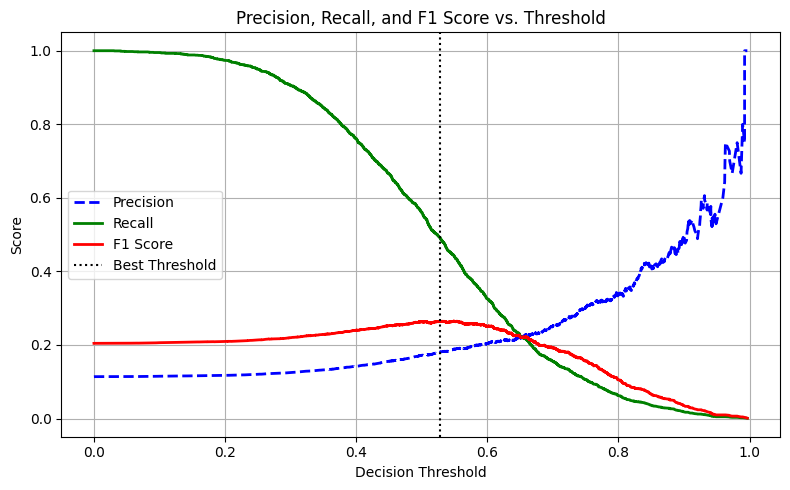

In [ ]:
best_thresh_lr = optimize_threshold(lr_pipeline, X_val, y_val)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Get the probabilities for the positive class
y_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# Apply the optimized threshold
y_pred_custom = (y_probs >= best_thresh_lr).astype(int)

print(f"[ Evaluation result with custom threshold: {best_thresh_lr:.4f} ]")
print("Classification report:")
print(classification_report(y_test, y_pred_custom))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_custom))

[ Evaluation result with custom threshold: 0.5285 ]
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80     17604
           1       0.18      0.48      0.26      2263

    accuracy                           0.69     19867
   macro avg       0.55      0.60      0.53     19867
weighted avg       0.83      0.69      0.74     19867

Confusion matrix:
[[12638  4966]
 [ 1179  1084]]


## Decision Tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", dt_model),
])

dt_cv = cross_validate(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

dt_cv_summary = summarize_cv_results(dt_cv, "Decision Tree")




CV summary for Decision Tree (mean ± std)
          accuracy: 0.6025 ± 0.0477
 balanced_accuracy: 0.5846 ± 0.0066
                f1: 0.2436 ± 0.0059
            pr_auc: 0.1836 ± 0.0086
         precision: 0.1564 ± 0.0076
            recall: 0.5615 ± 0.0628
           roc_auc: 0.6187 ± 0.0073


# Random Forest

In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     class_weight="balanced",
#     random_state=42,
#     n_jobs=-1
# )

# rf_pipeline = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", rf_model),
# ])

# # Using the same cross-validation setup as Logistic Regression
# # cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# # scoring = {
# #     "pr_auc": pr_auc_scorer,
# #     "f1": "f1",
# #     "recall": "recall",
# #     "precision": "precision"
# # }

# print("Performing cross-validation for Random Forest...")
# rf_cv_results = cross_validate(
#     rf_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=-1
# )

# print("\nRandom Forest CV Results:")
# for key in rf_cv_results:
#     if key.startswith("test_"):
#         print(key, np.mean(rf_cv_results[key]))

# rf_cv_summary = summarize_cv_results(rf_cv_results, "Random Forest")

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf_model),
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

rf_cv_summary = summarize_cv_results(rf_cv, "Random Forest")



CV summary for Random Forest (mean ± std)
          accuracy: 0.7695 ± 0.0047
 balanced_accuracy: 0.5885 ± 0.0105
                f1: 0.2592 ± 0.0134
            pr_auc: 0.2083 ± 0.0098
         precision: 0.2044 ± 0.0103
            recall: 0.3541 ± 0.0204
           roc_auc: 0.6521 ± 0.0107


In [ ]:
print("\nFitting Random Forest model on full training data and evaluating on test set...")
rf_pipeline.fit(X_train, y_train)
evaluate_model(rf_pipeline, "Random Forest", X_test, y_test)


Fitting Random Forest model on full training data and evaluating on test set...
[ Evaluation result for Random Forest ]
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     17604
           1       0.21      0.37      0.27      2263

    accuracy                           0.77     19867
   macro avg       0.56      0.60      0.57     19867
weighted avg       0.83      0.77      0.80     19867

Confusion matrix:
[[14496  3108]
 [ 1431   832]] 



## XGBoost

In [ ]:
# import xgboost as xgb
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE

# # Calculate the scale_pos_weight for handling class imbalance
# neg_count = (y_train == 0).sum()
# pos_count = (y_train == 1).sum()
# scale_pos_weight_value = neg_count / pos_count

# xgb_model = xgb.XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='aucpr',
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=4,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     min_child_weight=10,
#     random_state=42,
#     n_jobs=-1,
#     scale_pos_weight=scale_pos_weight_value
# )

# xgb_pipeline = ImbPipeline([
#     ("preprocess", preprocessor),
#     ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
#     ("model", xgb_model),
# ])

# print("Performing cross-validation for XGBoost...")
# xgb_cv_results = cross_validate(
#     xgb_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=-1
# )

# print("\nXGBoost CV Results:")
# for key in xgb_cv_results:
#     if key.startswith("test_"):
#         print(key, np.mean(xgb_cv_results[key]))

# xgb_cv_summary = summarize_cv_results(xgb_cv_results, "XGBoost")

import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value
)

xgb_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.30, random_state=RANDOM_STATE)),
    ("model", xgb_model),
])

xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

xgb_cv_summary = summarize_cv_results(xgb_cv, "XGBoost")



CV summary for XGBoost (mean ± std)
          accuracy: 0.6400 ± 0.0063
 balanced_accuracy: 0.6052 ± 0.0090
                f1: 0.2617 ± 0.0074
            pr_auc: 0.2117 ± 0.0081
         precision: 0.1707 ± 0.0049
            recall: 0.5602 ± 0.0183
           roc_auc: 0.6516 ± 0.0100


In [ ]:
print("\nFitting XGBoost model on full training data and evaluating on test set...")
xgb_pipeline.fit(X_train, y_train)
evaluate_model(xgb_pipeline, "XGBoost", X_test, y_test)


Fitting XGBoost model on full training data and evaluating on test set...
[ Evaluation result for XGBoost ]
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17604
           1       0.17      0.57      0.26      2263

    accuracy                           0.64     19867
   macro avg       0.55      0.61      0.51     19867
weighted avg       0.84      0.64      0.70     19867

Confusion matrix:
[[11389  6215]
 [  971  1292]] 



# LightGBM

In [ ]:
# import lightgbm as lgb
# from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# # Convert cat_cols to 'category' dtype (Crucial for LightGBM)

# # ── Preprocessor: no OHE — LightGBM handles categoricals natively ──
# numeric_transformer = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler",  StandardScaler())
# ])

# categorical_transformer = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("ord",     OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
# ])

# lgb_preprocessor = ColumnTransformer([
#     ("num", numeric_transformer,     num_cols),
#     ("cat", categorical_transformer, cat_cols)
# ])

# cat_feature_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
# print("Categorical feature indices:", cat_feature_indices)

# # ── Model ───────────────────────────────────────────────────────────
# lgb_model = lgb.LGBMClassifier(
#     objective="binary",
#     metric="average_precision",
#     n_estimators=1000,             # high ceiling — early stopping will trim it
#     learning_rate=0.05,
#     num_leaves=31,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=scale_pos_weight_value,  # is_unbalance=False (default)
#      categorical_feature=cat_feature_indices,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
# )

# # ── Pipeline with SMOTE ─────────────────────────────────────────────
# lgb_pipeline = ImbPipeline([
#     ("preprocessor", lgb_preprocessor),
#     ("smote",        SMOTE(sampling_strategy=0.2, random_state=42)),
#     ("model",        lgb_model)
# ])

# print("Performing cross-validation for LightGBM...")
# lgb_cv_results = cross_validate(
#     lgb_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=-1
# )

# print("\nLightGBM CV Results:")
# for key in lgb_cv_results:
#     if key.startswith("test_"):
#         print(key, np.mean(lgb_cv_results[key]))

# lgb_cv_summary = summarize_cv_results(lgb_cv_results, "LightGBM")

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    metric="average_precision",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_value,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_pipeline = ImbPipeline([
    ("preprocess", lgb_preprocessor),
    ("smote", SMOTE(sampling_strategy=0.20, random_state=RANDOM_STATE)),
    ("model", lgb_model),
])

lgb_cv = cross_validate(
    lgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

lgb_cv_summary = summarize_cv_results(lgb_cv, "LightGBM")



CV summary for LightGBM (mean ± std)
          accuracy: 0.7333 ± 0.0053
 balanced_accuracy: 0.5814 ± 0.0081
                f1: 0.2473 ± 0.0093
            pr_auc: 0.1935 ± 0.0084
         precision: 0.1823 ± 0.0073
            recall: 0.3845 ± 0.0136
           roc_auc: 0.6261 ± 0.0053


In [ ]:
print("\nFitting LightGBM model on full training data and evaluating on test set...")
lgb_pipeline.fit(X_train, y_train)
evaluate_model(lgb_pipeline, "LightGBM", X_test, y_test)


Fitting LightGBM model on full training data and evaluating on test set...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[ Evaluation result for LightGBM ]
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.83     17604
           1       0.18      0.43      0.26      2263

    accuracy                           0.72     19867
   macro avg       0.55      0.59      0.54     19867
weighted avg       0.83      0.72      0.76     19867

Confusion matrix:
[[13267  4337]
 [ 1290   973]] 



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Threshold for F1: 0.4523
Max F1-Score: 0.2572
Precision at best threshold: 0.1677
Recall at best threshold: 0.5514


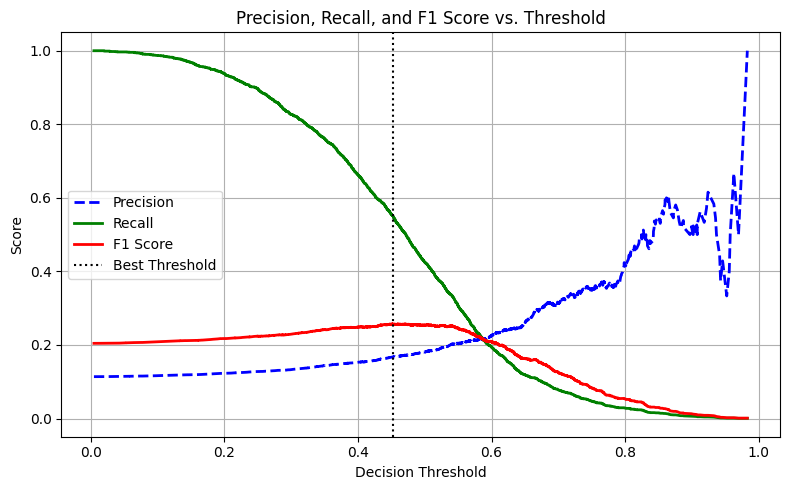

In [ ]:
best_thresh_lgbm = optimize_threshold(lgb_pipeline, X_val, y_val)

In [ ]:
# Get the probabilities for the positive class
y_probs = lgb_pipeline.predict_proba(X_test)[:, 1]

# Apply the optimized threshold
y_pred_custom = (y_probs >= best_thresh_lgbm).astype(int)

print(f"[ Evaluation result with custom threshold: {best_thresh_lgbm:.4f} ]")
print("Classification report:")
print(classification_report(y_test, y_pred_custom))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_custom))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[ Evaluation result with custom threshold: 0.4523 ]
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17604
           1       0.17      0.54      0.25      2263

    accuracy                           0.64     19867
   macro avg       0.54      0.60      0.51     19867
weighted avg       0.83      0.64      0.70     19867

Confusion matrix:
[[11393  6211]
 [ 1034  1229]]


## Neural Network baseline (MLPClassifier)


In [ ]:
# from sklearn.neural_network import MLPClassifier

# mlp_model = MLPClassifier(
#     hidden_layer_sizes=(128, 64),
#     activation="relu",
#     alpha=1e-4,
#     batch_size=256,
#     learning_rate_init=1e-3,
#     max_iter=50,
#     early_stopping=True,
#     random_state=RANDOM_STATE
# )

# mlp_pipeline = ImbPipeline([
#     ("preprocess", preprocessor),
#     ("smote", SMOTE(sampling_strategy=0.25, random_state=RANDOM_STATE)),
#     ("model", mlp_model),
# ])

# mlp_cv = cross_validate(
#     mlp_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=-1,
#     return_train_score=False
# )

# mlp_cv_summary = summarize_cv_results(mlp_cv, "MLP Neural Network")

from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    random_state=RANDOM_STATE
)

mlp_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.25, random_state=RANDOM_STATE)),
    ("model", mlp_model),
])

mlp_cv = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

mlp_cv_summary = summarize_cv_results(mlp_cv, "MLP Neural Network")




CV summary for MLP Neural Network (mean ± std)
          accuracy: 0.8446 ± 0.0025
 balanced_accuracy: 0.5186 ± 0.0022
                f1: 0.1239 ± 0.0054
            pr_auc: 0.1426 ± 0.0038
         precision: 0.1731 ± 0.0077
            recall: 0.0965 ± 0.0050
           roc_auc: 0.5631 ± 0.0059


## Cross-validation summary table


In [ ]:
# cv_summary_all = pd.concat(
#     [lr_cv_summary, dt_cv_summary, rf_cv_summary, xgb_cv_summary, lgb_cv_summary, mlp_cv_summary],
#     ignore_index=True
# )

# cv_pivot_mean = cv_summary_all.pivot(index="model", columns="metric", values="mean")
# cv_pivot_std = cv_summary_all.pivot(index="model", columns="metric", values="std")

# print("CV mean table")
# display(cv_pivot_mean.sort_values("pr_auc", ascending=False))

# print("CV std table")
# display(cv_pivot_std.loc[cv_pivot_mean.sort_values("pr_auc", ascending=False).index])

cv_summary_all = pd.concat(
    [lr_cv_summary, dt_cv_summary, rf_cv_summary, xgb_cv_summary, lgb_cv_summary, mlp_cv_summary],
    ignore_index=True
)

cv_pivot_mean = cv_summary_all.pivot(index="model", columns="metric", values="mean")
cv_pivot_std = cv_summary_all.pivot(index="model", columns="metric", values="std")

print("CV mean table")
display(cv_pivot_mean.sort_values("pr_auc", ascending=False))

print("CV std table")
display(cv_pivot_std.loc[cv_pivot_mean.sort_values("pr_auc", ascending=False).index])



CV mean table


metric,accuracy,balanced_accuracy,f1,pr_auc,precision,recall,roc_auc
model,,,,,,,
XGBoost,0.639967,0.605219,0.261671,0.211655,0.170717,0.560221,0.651635
Random Forest,0.769490,0.588508,0.259177,0.208261,0.204417,0.354144,0.652085
LightGBM,0.733342,0.581351,0.247285,0.193482,0.182258,0.384530,0.626140
Logistic Regression,0.642610,0.594914,0.253588,0.193086,0.166364,0.533149,0.631857
Decision Tree,0.602467,0.584601,0.243616,0.183566,0.156369,0.561464,0.618724
MLP Neural Network,0.844554,0.518619,0.123903,0.142573,0.173148,0.096547,0.563133


CV std table


metric,accuracy,balanced_accuracy,f1,pr_auc,precision,recall,roc_auc
model,,,,,,,
XGBoost,0.006253,0.008975,0.007401,0.008069,0.004864,0.018321,0.010039
Random Forest,0.004736,0.010460,0.013398,0.009790,0.010307,0.020386,0.010731
LightGBM,0.005301,0.008100,0.009337,0.008439,0.007310,0.013592,0.005324
Logistic Regression,0.004405,0.009515,0.007938,0.005276,0.005067,0.019174,0.012036
Decision Tree,0.047674,0.006560,0.005921,0.008627,0.007583,0.062805,0.007309
MLP Neural Network,0.002503,0.002198,0.005420,0.003831,0.007696,0.005007,0.005903


## Model Selection Summary  

We evaluated multiple supervised learning models using a unified preprocessing pipeline and stratified 5-fold cross-validation to address class imbalance in the hospital readmission prediction task. Each model was implemented using baseline or moderately tuned hyperparameters, together with imbalance-aware learning strategies.

- **Logistic Regression** was used as a linear baseline model, configured with `class_weight="balanced"` and an increased iteration limit (`max_iter=2000`) to ensure stable convergence on the standardized feature space.

- **Decision Tree** was included as a simple nonlinear baseline to capture hierarchical feature interactions without strong distributional assumptions.

- **Random Forest** was implemented with `n_estimators=100` and `class_weight="balanced"` to improve predictive robustness through ensemble averaging while reducing bias toward the majority class.

- **XGBoost** was configured with `n_estimators=500`, `max_depth=4`, and `learning_rate=0.05`. SMOTE oversampling was incorporated within the training pipeline to improve minority-class recall while ensuring leakage-safe preprocessing inside each cross-validation fold.

- **LightGBM** was implemented with `n_estimators=1000`, `num_leaves=31`, and `learning_rate=0.05`, together with SMOTE oversampling inside the pipeline. A dedicated preprocessing configuration using ordinal encoding for categorical variables was applied to better leverage LightGBM’s efficient histogram-based tree learning mechanism.

- **Neural Network (MLPClassifier)** was introduced as an additional nonlinear baseline with hidden layers `(128, 64)`, ReLU activation, mini-batch training, and early stopping. This model provides a gradient-based learning comparison against tree-based ensemble approaches.

Model performance was evaluated using multiple metrics, with particular emphasis on **PR-AUC, Recall, and F1-score**, which are more informative than accuracy for highly imbalanced clinical prediction problems. Cross-validation results were aggregated into a comparative summary table to identify the most clinically useful model.

In addition, a **cost-sensitive decision threshold tuning step** was applied during final evaluation to prioritize recall and reduce false negatives. This reflects the real-world clinical objective of minimizing missed high-risk patient readmissions.


# Apply RandomizedSearchCV
systematically searches for the best combination of parameters to maximize your model's performance (like PR-AUC or F1-score) before you apply your cost-sensitive threshold. It is also much faster than GridSearchCV.

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# param_grid = {
#     "model__n_estimators":      [300, 500, 700],
#     "model__max_depth":         [3, 4, 5],
#     "model__learning_rate":     [0.01, 0.05, 0.1],
#     "model__subsample":         [0.7, 0.8, 0.9],
#     "model__colsample_bytree":  [0.6, 0.7, 0.8],
#     "model__min_child_weight":  [5, 10, 20],
#     "model__gamma":             [0, 0.1, 0.3],
#     "smote__sampling_strategy": [0.15, 0.2, 0.25],
# }

# xgb_search = RandomizedSearchCV(
#     xgb_pipeline,
#     param_grid,
#     n_iter=30,
#     scoring="average_precision",
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# xgb_search.fit(X_train, y_train)

# print(f"Best CV PR-AUC: {xgb_search.best_score_:.4f}")
# print(f"Best params:    {xgb_search.best_params_}")

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    "model__min_child_weight": [5, 10, 20],
    "model__gamma": [0, 0.1, 0.3],
    "smote__sampling_strategy": [0.15, 0.20, 0.25],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best CV PR-AUC:", xgb_search.best_score_)
print("Best params:", xgb_search.best_params_)

best_model = xgb_search.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV PR-AUC: 0.21167649775490022
Best params: {'smote__sampling_strategy': 0.2, 'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_child_weight': 20, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}


## Autoencoder Baseline for Tabular Readmission Modeling

In addition to supervised classifiers, we include an autoencoder-based baseline for tabular patient data. The autoencoder is trained to reconstruct the preprocessed input features, and the reconstruction error is used as a risk score. Patients with larger reconstruction errors are treated as more unusual or difficult-to-reconstruct cases, which may correspond to higher readmission risk.

To keep the evaluation leakage-safe, the reconstruction-error threshold is selected on the validation set, and final performance is reported once on the untouched test set.


In [ ]:
# Autoencoder needs dense numeric arrays
ae_preprocessor = preprocessor

X_train_ae = ae_preprocessor.fit_transform(X_train)
X_val_ae   = ae_preprocessor.transform(X_val)
X_test_ae  = ae_preprocessor.transform(X_test)

# Convert sparse to dense if needed
if hasattr(X_train_ae, "toarray"):
    X_train_ae = X_train_ae.toarray()
    X_val_ae   = X_val_ae.toarray()
    X_test_ae  = X_test_ae.toarray()

print("AE train shape:", X_train_ae.shape)
print("AE val shape:  ", X_val_ae.shape)
print("AE test shape: ", X_test_ae.shape)


AE train shape: (63572, 2209)
AE val shape:   (15894, 2209)
AE test shape:  (19867, 2209)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

input_dim = X_train_ae.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


Device: cpu


In [ ]:
X_train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_ae, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_ae, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor),
    batch_size=256,
    shuffle=False
)


In [ ]:
ae_model = Autoencoder(input_dim=input_dim, latent_dim=32).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

num_epochs = 20

for epoch in range(num_epochs):
    ae_model.train()
    train_loss = 0.0

    for (xb,) in train_loader:
        xb = xb.to(device)

        optimizer.zero_grad()
        xb_hat = ae_model(xb)
        loss = criterion(xb_hat, xb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    ae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device)
            xb_hat = ae_model(xb)
            loss = criterion(xb_hat, xb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")


Epoch 01 | train loss: 0.010635 | val loss: 0.006410
Epoch 02 | train loss: 0.005709 | val loss: 0.005012
Epoch 03 | train loss: 0.004854 | val loss: 0.004230
Epoch 04 | train loss: 0.003993 | val loss: 0.003790
Epoch 05 | train loss: 0.003629 | val loss: 0.003329
Epoch 06 | train loss: 0.003179 | val loss: 0.003029
Epoch 07 | train loss: 0.002972 | val loss: 0.002908
Epoch 08 | train loss: 0.002826 | val loss: 0.002777
Epoch 09 | train loss: 0.002747 | val loss: 0.002672
Epoch 10 | train loss: 0.002641 | val loss: 0.002645
Epoch 11 | train loss: 0.002591 | val loss: 0.002501
Epoch 12 | train loss: 0.002455 | val loss: 0.002418
Epoch 13 | train loss: 0.002405 | val loss: 0.002373
Epoch 14 | train loss: 0.002344 | val loss: 0.002568
Epoch 15 | train loss: 0.002340 | val loss: 0.002315
Epoch 16 | train loss: 0.002260 | val loss: 0.002229
Epoch 17 | train loss: 0.002209 | val loss: 0.002213
Epoch 18 | train loss: 0.002207 | val loss: 0.002183
Epoch 19 | train loss: 0.002213 | val loss: 0.

In [ ]:
def reconstruction_errors(model, X_array, batch_size=256):
    model.eval()
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

    errs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            xb_hat = model(xb)
            batch_err = torch.mean((xb_hat - xb) ** 2, dim=1)
            errs.append(batch_err.cpu().numpy())

    return np.concatenate(errs)

train_err = reconstruction_errors(ae_model, X_train_ae)
val_err   = reconstruction_errors(ae_model, X_val_ae)
test_err  = reconstruction_errors(ae_model, X_test_ae)

print("Validation error summary:")
print(pd.Series(val_err).describe())


Validation error summary:
count    15894.000000
mean         0.002239
std          0.001095
min          0.000566
25%          0.001787
50%          0.002231
75%          0.002651
max          0.073631
dtype: float64


In [ ]:
# Treat reconstruction error as a risk score
ae_best_f1_point = choose_best_f1_threshold(y_val, val_err)
ae_recall80_point = choose_threshold_for_target_recall(y_val, val_err, target_recall=0.80)
ae_fpr20_point = choose_threshold_for_target_fpr(y_val, val_err, max_fpr=0.20)

print("AE best validation F1 threshold:")
print(ae_best_f1_point)

print("\nAE validation threshold with recall >= 0.80:")
print(ae_recall80_point)

print("\nAE validation threshold with FPR <= 0.20:")
print(ae_fpr20_point)

ae_selected_threshold = (
    ae_recall80_point["threshold"] if ae_recall80_point is not None
    else ae_best_f1_point["threshold"]
)

print(f"\nSelected AE threshold: {ae_selected_threshold:.6f}")


AE best validation F1 threshold:
{'threshold': 0.0013747971970587969, 'precision': 0.11695784803105934, 'recall': 0.9320441988950277, 'f1': 0.2078354071699386}

AE validation threshold with recall >= 0.80:
{'threshold': 0.0017156978137791157, 'precision': 0.11792186870720903, 'recall': 0.8088397790055248, 'f1': 0.20583479789081482}

AE validation threshold with FPR <= 0.20:
{'threshold': 0.0027356965001672506, 'fpr': 0.19973019028685032, 'recall': 0.20994475138121546, 'precision': 0.11901033510804886, 'f1': 0.15190885468718768}

Selected AE threshold: 0.001716



[Autoencoder — TEST]
         threshold: 0.0017
          accuracy: 0.2856
 balanced_accuracy: 0.5091
         precision: 0.1163
            recall: 0.7985
                f1: 0.2030
           roc_auc: 0.5177
            pr_auc: 0.1241

Classification report:
              precision    recall  f1-score   support

           0     0.8945    0.2197    0.3527     17604
           1     0.1163    0.7985    0.2030      2263

    accuracy                         0.2856     19867
   macro avg     0.5054    0.5091    0.2778     19867
weighted avg     0.8059    0.2856    0.3357     19867



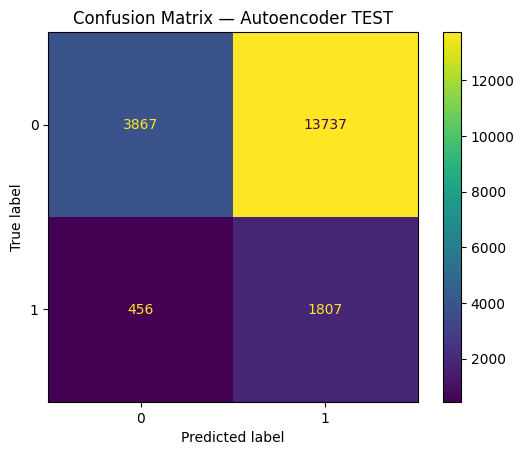

In [ ]:
ae_test_metrics = compute_metrics_from_probs(
    y_true=y_test,
    y_prob=test_err,
    threshold=ae_selected_threshold
)

print_metric_block("Autoencoder — TEST", ae_test_metrics)

print("\nClassification report:")
print(classification_report(
    y_test,
    ae_test_metrics["y_pred"],
    digits=4,
    zero_division=0
))

disp = ConfusionMatrixDisplay(ae_test_metrics["confusion_matrix"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Autoencoder TEST")
plt.show()


In [ ]:
ae_summary_row = pd.DataFrame([{
    "model": "Autoencoder",
    "threshold": ae_selected_threshold,
    "accuracy": ae_test_metrics["accuracy"],
    "balanced_accuracy": ae_test_metrics["balanced_accuracy"],
    "precision": ae_test_metrics["precision"],
    "recall": ae_test_metrics["recall"],
    "f1": ae_test_metrics["f1"],
    "roc_auc": ae_test_metrics["roc_auc"],
    "pr_auc": ae_test_metrics["pr_auc"],
}])

display(ae_summary_row)


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Autoencoder,0.001716,0.285599,0.509082,0.116251,0.798498,0.202954,0.517732,0.124065


## Autoencoder Result Summary

We additionally evaluated an autoencoder-based baseline on the tabular patient dataset. The model was trained to reconstruct the preprocessed input features, and reconstruction error was used as a readmission-risk score. A decision threshold was selected on the validation set to preserve leakage-safe evaluation.

This autoencoder provides a useful deep-learning comparison against both classical supervised models and the MLP baseline. While it does not directly optimize the readmission label during training, it can identify difficult-to-reconstruct or unusual patient patterns that may correlate with elevated readmission risk.


# Threshold Tuning on Validation Set Only

To align with leakage-safe evaluation, decision thresholds are selected using the validation set rather than the test set.

We examine:
- the threshold that maximizes validation F1-score
- the threshold that achieves a target recall level
- the threshold under a fixed false-positive-rate constraint

This supports a cost-sensitive policy for clinical prediction, where missing high-risk readmissions can be more costly than false alarms.


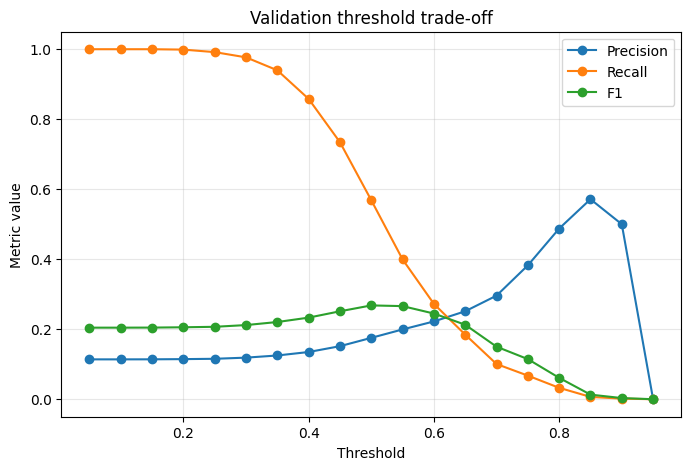

Best validation F1 threshold:
{'threshold': 0.5129627585411072, 'precision': 0.18653958373857227, 'recall': 0.5298342541436464, 'f1': 0.2759315206441264}

Validation threshold with recall >= 0.80:
{'threshold': 0.42734456062316895, 'precision': 0.14333728746540134, 'recall': 0.8011049723756906, 'f1': 0.24316619151408095}

Validation threshold with FPR <= 0.20:
{'threshold': 0.5528292655944824, 'fpr': 0.19987219539903436, 'recall': 0.3911602209944751, 'precision': 0.20096508657394266, 'f1': 0.2655165947871742}


In [ ]:
# # Use your chosen final candidate model here.
# # If XGBoost is your finalist, best_model should already be your tuned XGBoost pipeline.
# # Example:
# # best_model = xgb_search.best_estimator_

# xgb_search.fit(X_train, y_train)
# best_model = xgb_search.best_estimator_

# val_prob = get_positive_probs(best_model, X_val)

# plot_threshold_tradeoff(
#     y_val,
#     val_prob,
#     title="Validation threshold trade-off"
# )

# best_f1_point = choose_best_f1_threshold(y_val, val_prob)
# recall80_point = choose_threshold_for_target_recall(y_val, val_prob, target_recall=0.80)
# fpr20_point = choose_threshold_for_target_fpr(y_val, val_prob, max_fpr=0.20)

# print("Best validation F1 threshold:")
# print(best_f1_point)

# print("\nValidation threshold with recall >= 0.80:")
# print(recall80_point)

# print("\nValidation threshold with FPR <= 0.20:")
# print(fpr20_point)

# best_model already comes from RandomizedSearchCV above
val_prob = get_positive_probs(best_model, X_val)

plot_threshold_tradeoff(
    y_val,
    val_prob,
    title="Validation threshold trade-off"
)

best_f1_point = choose_best_f1_threshold(y_val, val_prob)
recall80_point = choose_threshold_for_target_recall(y_val, val_prob, target_recall=0.80)
fpr20_point = choose_threshold_for_target_fpr(y_val, val_prob, max_fpr=0.20)

print("Best validation F1 threshold:")
print(best_f1_point)

print("\nValidation threshold with recall >= 0.80:")
print(recall80_point)

print("\nValidation threshold with FPR <= 0.20:")
print(fpr20_point)


## Validation Operating-Point Table

The table below compares multiple candidate thresholds on the validation set.  
This allows us to explicitly choose a cost-sensitive threshold that prioritizes recall while still keeping precision and false positive rate at acceptable levels.


In [ ]:
# candidate_thresholds = sorted(set([
#     0.10, 0.20, 0.30, 0.40, 0.50,
#     round(best_f1_point["threshold"], 4),
#     round(recall80_point["threshold"], 4) if recall80_point is not None else 0.50,
#     round(fpr20_point["threshold"], 4) if fpr20_point is not None else 0.50,
# ]))

# val_op_table = operating_point_table(y_val, val_prob, candidate_thresholds).sort_values("threshold")
# display(val_op_table)

# selected_threshold = recall80_point["threshold"] if recall80_point is not None else best_f1_point["threshold"]
# print(f"Selected threshold for final reporting: {selected_threshold:.4f}")

candidate_thresholds = sorted(set([
    0.10, 0.20, 0.30, 0.40, 0.50,
    round(best_f1_point["threshold"], 4),
    round(recall80_point["threshold"], 4) if recall80_point is not None else 0.50,
    round(fpr20_point["threshold"], 4) if fpr20_point is not None else 0.50,
]))

val_op_table = operating_point_table(y_val, val_prob, candidate_thresholds).sort_values("threshold")
display(val_op_table)

selected_threshold = recall80_point["threshold"] if recall80_point is not None else best_f1_point["threshold"]
print(f"Selected threshold for final reporting: {selected_threshold:.4f}")



,threshold,precision,recall,f1,accuracy,balanced_accuracy,roc_auc,pr_auc,fpr,tn,fp,fn,tp
0,0.1000,0.113879,1.000000,0.204474,0.113879,0.500000,0.653634,0.209412,1.000000,0,14084,0,1810
1,0.2000,0.114568,0.998895,0.205560,0.120737,0.503388,0.653634,0.209412,0.992119,111,13973,2,1808
2,0.3000,0.118809,0.976796,0.211851,0.172329,0.522870,0.653634,0.209412,0.931057,971,13113,42,1768
3,0.4000,0.134891,0.858011,0.233131,0.357179,0.575413,0.653634,0.209412,0.707185,4124,9960,257,1553
4,0.4273,0.143295,0.801105,0.243105,0.431924,0.592792,0.653634,0.209412,0.615521,5415,8669,360,1450
5,0.5000,0.175358,0.568508,0.268039,0.646407,0.612463,0.653634,0.209412,0.343581,9245,4839,781,1029
6,0.5130,0.186418,0.529282,0.275723,0.683340,0.616210,0.653634,0.209412,0.296862,9903,4181,852,958
7,0.5528,0.200965,0.391160,0.265517,0.753555,0.595644,0.653634,0.209412,0.199872,11269,2815,1102,708


Selected threshold for final reporting: 0.4273


### Threshold Selection Rationale

Because false negatives are clinically costly in hospital readmission prediction, we prioritize a threshold that achieves high recall on the validation set. This allows the final classifier to better identify high-risk patients, even if that comes at the cost of additional false positives.

The selected threshold is therefore more aligned with clinical decision support than the default 0.50 cutoff.


# Final Evaluation on the Untouched Test Set

After selecting the operating threshold on the validation set, we refit the final model on the combined training and validation data and evaluate it once on the untouched test set.

We report performance at:
- the default threshold of 0.50
- the selected cost-sensitive threshold



[Final model — TEST @ 0.50]
         threshold: 0.5000
          accuracy: 0.6414
 balanced_accuracy: 0.6101
         precision: 0.1733
            recall: 0.5696
                f1: 0.2657
           roc_auc: 0.6530
            pr_auc: 0.2087

Classification report:
              precision    recall  f1-score   support

           0     0.9216    0.6506    0.7627     17604
           1     0.1733    0.5696    0.2657      2263

    accuracy                         0.6414     19867
   macro avg     0.5474    0.6101    0.5142     19867
weighted avg     0.8364    0.6414    0.7061     19867



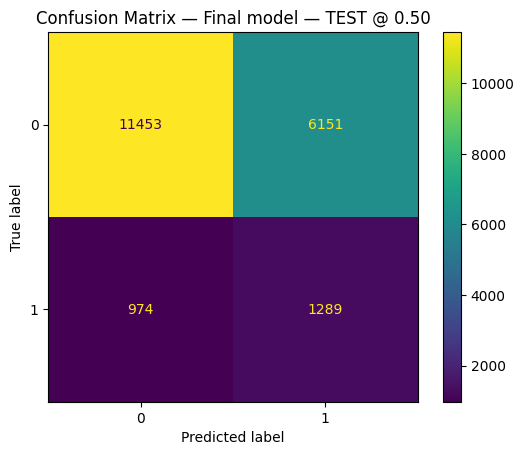


[Final model — TEST @ selected threshold (0.4273)]
         threshold: 0.4273
          accuracy: 0.4306
 balanced_accuracy: 0.5903
         precision: 0.1425
            recall: 0.7972
                f1: 0.2418
           roc_auc: 0.6530
            pr_auc: 0.2087

Classification report:
              precision    recall  f1-score   support

           0     0.9363    0.3834    0.5441     17604
           1     0.1425    0.7972    0.2418      2263

    accuracy                         0.4306     19867
   macro avg     0.5394    0.5903    0.3929     19867
weighted avg     0.8459    0.4306    0.5096     19867



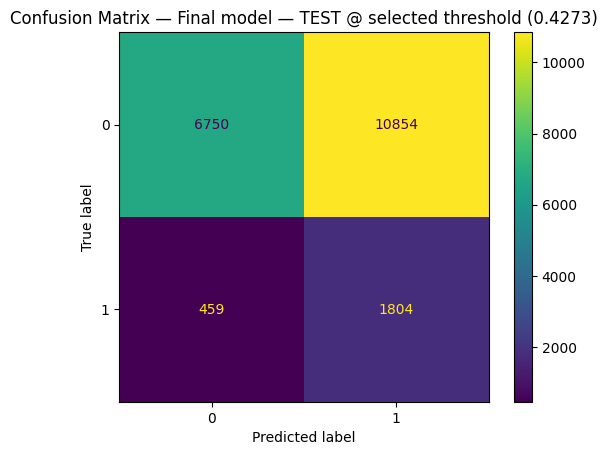

In [ ]:
# # Refit final model on train + validation
# X_train_final = pd.concat([X_train, X_val], axis=0)
# y_train_final = pd.concat([y_train, y_val], axis=0)

# best_model.fit(X_train_final, y_train_final)

# # Default threshold evaluation
# default_test_metrics, test_prob = evaluate_split(
#     best_model,
#     X_test,
#     y_test,
#     split_name="Final model — TEST @ 0.50",
#     threshold=0.50,
#     show_confusion=True
# )

# # Cost-sensitive threshold evaluation
# selected_test_metrics, test_prob = evaluate_split(
#     best_model,
#     X_test,
#     y_test,
#     split_name=f"Final model — TEST @ selected threshold ({selected_threshold:.4f})",
#     threshold=selected_threshold,
#     show_confusion=True
# )

X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_train_final, y_train_final)

default_test_metrics, test_prob = evaluate_split(
    best_model,
    X_test,
    y_test,
    split_name="Final model — TEST @ 0.50",
    threshold=0.50,
    show_confusion=True
)

selected_test_metrics, test_prob = evaluate_split(
    best_model,
    X_test,
    y_test,
    split_name=f"Final model — TEST @ selected threshold ({selected_threshold:.4f})",
    threshold=selected_threshold,
    show_confusion=True
)



## Final Threshold Comparison Table

This table compares the final test-set performance of the model under the default threshold and the selected cost-sensitive threshold.


In [ ]:
# final_summary = pd.DataFrame([
#     {"setting": "default_0.50", **{k: v for k, v in default_test_metrics.items() if k not in ["confusion_matrix", "y_pred"]}},
#     {"setting": "selected_threshold", **{k: v for k, v in selected_test_metrics.items() if k not in ["confusion_matrix", "y_pred"]}},
# ])

# display(final_summary)

final_summary = pd.DataFrame([
    {"setting": "default_0.50", **{k: v for k, v in default_test_metrics.items() if k not in ["confusion_matrix", "y_pred"]}},
    {"setting": "selected_threshold", **{k: v for k, v in selected_test_metrics.items() if k not in ["confusion_matrix", "y_pred"]}},
])

display(final_summary)



,setting,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,default_0.50,0.500000,0.641365,0.610094,0.173253,0.569598,0.265691,0.652981,0.208699
1,selected_threshold,0.427345,0.430563,0.590304,0.142519,0.797172,0.241807,0.652981,0.208699


## Train / Validation / Test Comparison

To assess possible overfitting, we compare model performance across the training, validation, and test sets using the same selected threshold.


In [ ]:
# overfit_compare_df = compare_train_val_test(
#     best_model,
#     X_train_final, y_train_final,
#     X_val, y_val,
#     X_test, y_test,
#     threshold=selected_threshold,
#     model_name="Final Selected Model"
# )

overfit_compare_df = compare_train_val_test(
    best_model,
    X_train_final, y_train_final,
    X_val, y_val,
    X_test, y_test,
    threshold=selected_threshold,
    model_name="Final Selected Model"
)

display(overfit_compare_df)




[Final Selected Model — TRAIN]
         threshold: 0.4273
          accuracy: 0.4378
 balanced_accuracy: 0.6105
         precision: 0.1488
            recall: 0.8341
                f1: 0.2526
           roc_auc: 0.6832
            pr_auc: 0.2346

Classification report:
              precision    recall  f1-score   support

           0     0.9478    0.3869    0.5495     70416
           1     0.1488    0.8341    0.2526      9050

    accuracy                         0.4378     79466
   macro avg     0.5483    0.6105    0.4011     79466
weighted avg     0.8568    0.4378    0.5157     79466


[Final Selected Model — VALIDATION]
         threshold: 0.4273
          accuracy: 0.4370
 balanced_accuracy: 0.6096
         precision: 0.1485
            recall: 0.8331
                f1: 0.2521
           roc_auc: 0.6819
            pr_auc: 0.2308

Classification report:
              precision    recall  f1-score   support

           0     0.9474    0.3861    0.5486     14084
           1   

,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,train,0.427345,0.437848,0.610529,0.148837,0.834144,0.252602,0.683211,0.234552
1,validation,0.427345,0.437020,0.609631,0.148513,0.833149,0.252090,0.681887,0.230829
2,test,0.427345,0.430563,0.590304,0.142519,0.797172,0.241807,0.652981,0.208699


## Final Model Comparison Summary


In [ ]:
final_model_compare = pd.DataFrame([
    {
        "model": "Tuned XGBoost @ default 0.50",
        "accuracy": default_test_metrics["accuracy"],
        "balanced_accuracy": default_test_metrics["balanced_accuracy"],
        "precision": default_test_metrics["precision"],
        "recall": default_test_metrics["recall"],
        "f1": default_test_metrics["f1"],
        "roc_auc": default_test_metrics["roc_auc"],
        "pr_auc": default_test_metrics["pr_auc"],
    },
    {
        "model": "Tuned XGBoost @ selected threshold",
        "accuracy": selected_test_metrics["accuracy"],
        "balanced_accuracy": selected_test_metrics["balanced_accuracy"],
        "precision": selected_test_metrics["precision"],
        "recall": selected_test_metrics["recall"],
        "f1": selected_test_metrics["f1"],
        "roc_auc": selected_test_metrics["roc_auc"],
        "pr_auc": selected_test_metrics["pr_auc"],
    },
    {
        "model": "Autoencoder",
        "accuracy": ae_test_metrics["accuracy"],
        "balanced_accuracy": ae_test_metrics["balanced_accuracy"],
        "precision": ae_test_metrics["precision"],
        "recall": ae_test_metrics["recall"],
        "f1": ae_test_metrics["f1"],
        "roc_auc": ae_test_metrics["roc_auc"],
        "pr_auc": ae_test_metrics["pr_auc"],
    }
])

display(final_model_compare)


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned XGBoost @ default 0.50,0.641365,0.610094,0.173253,0.569598,0.265691,0.652981,0.208699
1,Tuned XGBoost @ selected threshold,0.430563,0.590304,0.142519,0.797172,0.241807,0.652981,0.208699
2,Autoencoder,0.285599,0.509082,0.116251,0.798498,0.202954,0.517732,0.124065


## Feature Importance / Model Interpretation


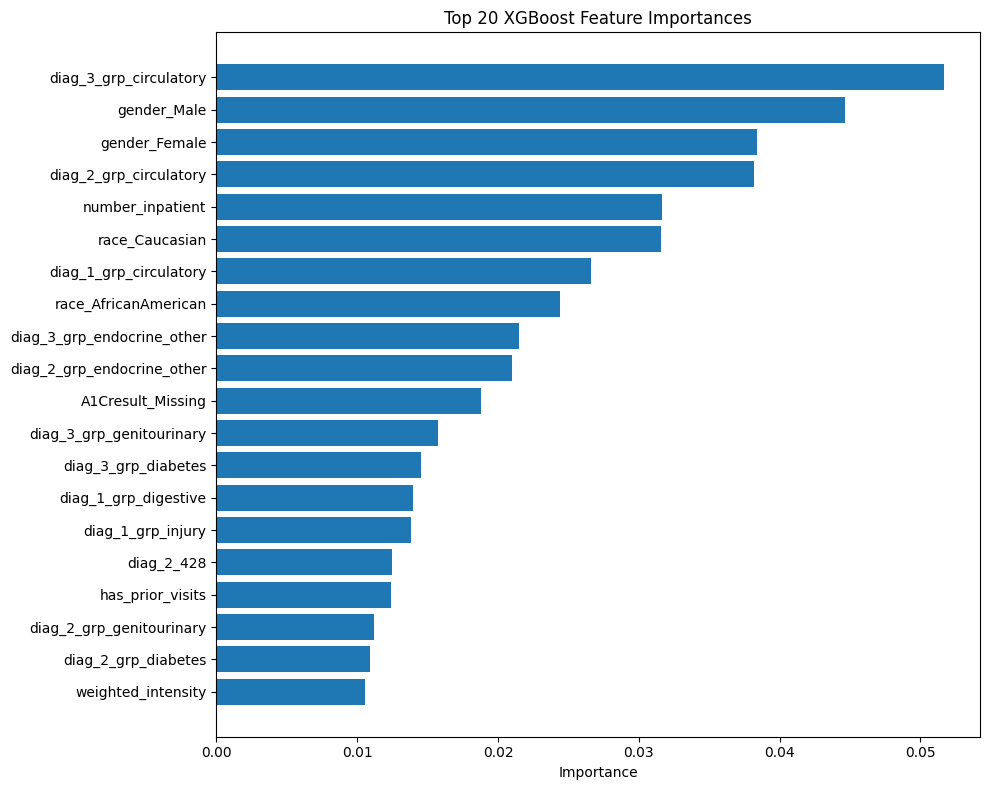

,feature,importance
2270,diag_3_grp_circulatory,0.051645
37,gender_Male,0.044643
36,gender_Female,0.038405
2251,diag_2_grp_circulatory,0.038150
7,number_inpatient,0.031671
32,race_Caucasian,0.031575
2232,diag_1_grp_circulatory,0.026591
30,race_AfricanAmerican,0.024419
2273,diag_3_grp_endocrine_other,0.021525
2254,diag_2_grp_endocrine_other,0.020978


In [ ]:
feature_names = [f.split("__")[-1] for f in best_model["preprocess"].get_feature_names_out()]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model["model"].feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

display(importance_df)


# Final Project Conclusions

This project formulates hospital readmission prediction as a **binary classification** task, where readmission within 30 days (`<30`) is the positive class and all other outcomes are treated as the negative class.

To address severe class imbalance and clinical cost sensitivity, we evaluated multiple supervised learning models using stratified cross-validation, PR-AUC-focused evaluation, and leakage-safe preprocessing pipelines. For models using SMOTE, oversampling was performed inside the training pipeline so that synthetic samples were generated only from training folds.

We additionally evaluated an autoencoder-based baseline using reconstruction error as a risk score. This provided a useful deep-learning comparison against the supervised models.

A cost-sensitive threshold selection strategy was applied using a separate validation set, allowing the final model to prioritize recall and reduce missed high-risk patient readmissions. Final performance was then reported once on the untouched test set, ensuring that evaluation remained unbiased and consistent with real-world deployment considerations.


# Cost-sensitive decison policy
Add a cost-sensitive decision policy: since false negatives are costly, state how you’ll pick an operating point (threshold tuned to a target recall or a fixed false-alarm rate) and report the resulting precision/recall tradeoff as part of “what success looks like.”
- try assigning target recall

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def find_threshold_for_recall(model, X_val, y_val, target_recall=0.8):
    """
    Finds the decision threshold that achieves a target Recall while maximizing Precision.
    """
    # Get probabilities for the positive class
    y_probs = model.predict_proba(X_val)[:, 1]

    # Calculate precision, recall, and thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs)

    # Find all indices where recall >= target_recall
    valid_indices = np.where(recalls >= target_recall)[0]

    if len(valid_indices) == 0:
        print(f"Cannot achieve target recall of {target_recall}")
        return None

    # From these valid indices, find the index that gives the maximum precision
    best_valid_idx = valid_indices[np.argmax(precisions[valid_indices])]

    # Handle the case where the best index is the last element (thresholds has length n-1)
    if best_valid_idx >= len(thresholds):
        best_threshold = 1.0
    else:
        best_threshold = thresholds[best_valid_idx]

    best_precision = precisions[best_valid_idx]
    best_recall = recalls[best_valid_idx]

    print(f"Target Recall: {target_recall}")
    print(f"Optimal Threshold: {best_threshold:.4f}")
    print(f"Precision at this threshold: {best_precision:.4f}")
    print(f"Recall at this threshold: {best_recall:.4f}")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(recalls, precisions, "b-", linewidth=2, label="Precision-Recall curve")
    plt.plot(best_recall, best_precision, 'ro', markersize=8, label=f"Target (Rec >= {target_recall})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Target Recall={target_recall})")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_threshold

## Apply Cost-Sensitive Policy to XGBoost


Target Recall: 0.65
Optimal Threshold: 0.4775
Precision at this threshold: 0.1636
Recall at this threshold: 0.6519


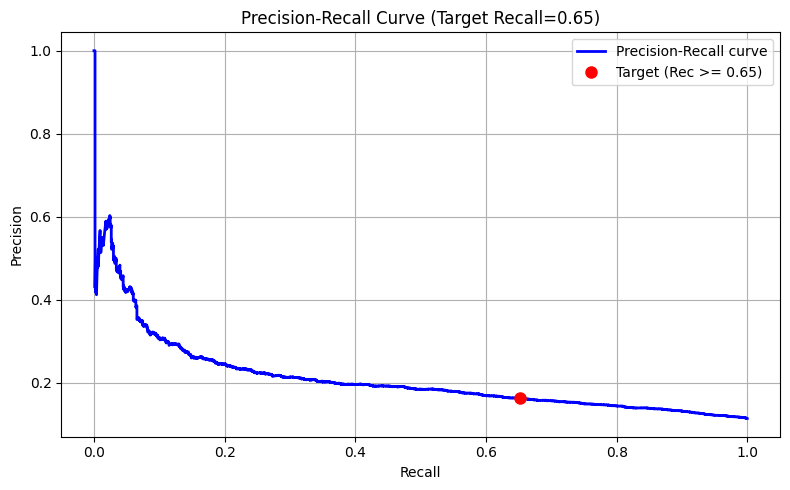


Saved Cost-Sensitive Threshold: 0.4775


In [ ]:
threh_65 = find_threshold_for_recall(xgb_pipeline, X_val, y_val, target_recall=0.65)
print(f"\nSaved Cost-Sensitive Threshold: {threh_65:.4f}")

Target Recall: 0.8
Optimal Threshold: 0.4253
Precision at this threshold: 0.1440
Recall at this threshold: 0.8000


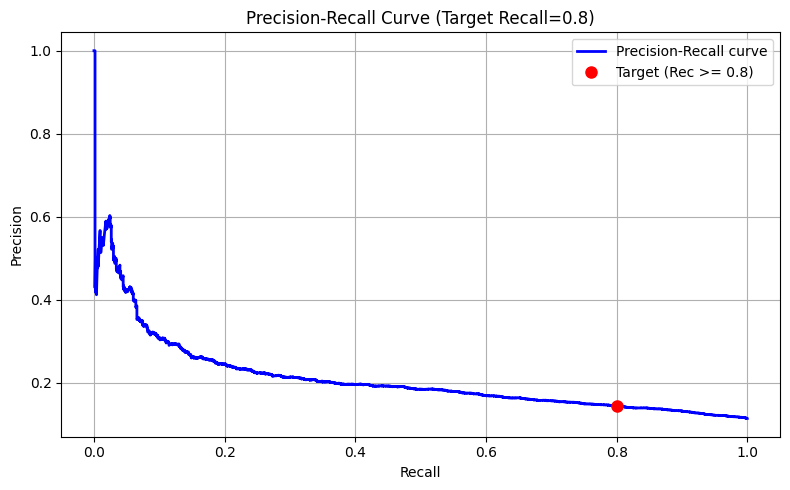


Saved Cost-Sensitive Threshold: 0.4253


In [ ]:
threh_80 = find_threshold_for_recall(xgb_pipeline, X_val, y_val, target_recall=0.80)
print(f"\nSaved Cost-Sensitive Threshold: {threh_80:.4f}")

## Evaluate Cost-Sensitive Trade-off


In [ ]:
y_probs_cs = xgb_pipeline.predict_proba(X_test)[:, 1]

# recall 65%
y_pred_cs = (y_probs_cs >= threh_65).astype(int)

print(f"[ Evaluation result with cost-sensitive threshold: {threh_65:.4f} ]")
print("Classification report:")
print(classification_report(y_test, y_pred_cs))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_cs))

[ Evaluation result with cost-sensitive threshold: 0.4775 ]
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.57      0.71     17604
           1       0.16      0.64      0.26      2263

    accuracy                           0.58     19867
   macro avg       0.54      0.61      0.48     19867
weighted avg       0.84      0.58      0.66     19867

Confusion matrix:
[[10098  7506]
 [  821  1442]]


In [ ]:
y_probs_cs = xgb_pipeline.predict_proba(X_test)[:, 1]

# recall 80%
y_pred_cs = (y_probs_cs >= threh_80).astype(int)

print(f"[ Evaluation result with cost-sensitive threshold: {threh_80:.4f} ]")
print("Classification report:")
print(classification_report(y_test, y_pred_cs))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_cs))

[ Evaluation result with cost-sensitive threshold: 0.4253 ]
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.39      0.55     17604
           1       0.14      0.79      0.24      2263

    accuracy                           0.44     19867
   macro avg       0.54      0.59      0.40     19867
weighted avg       0.84      0.44      0.51     19867

Confusion matrix:
[[ 6863 10741]
 [  481  1782]]


⬆this one is probably the best.

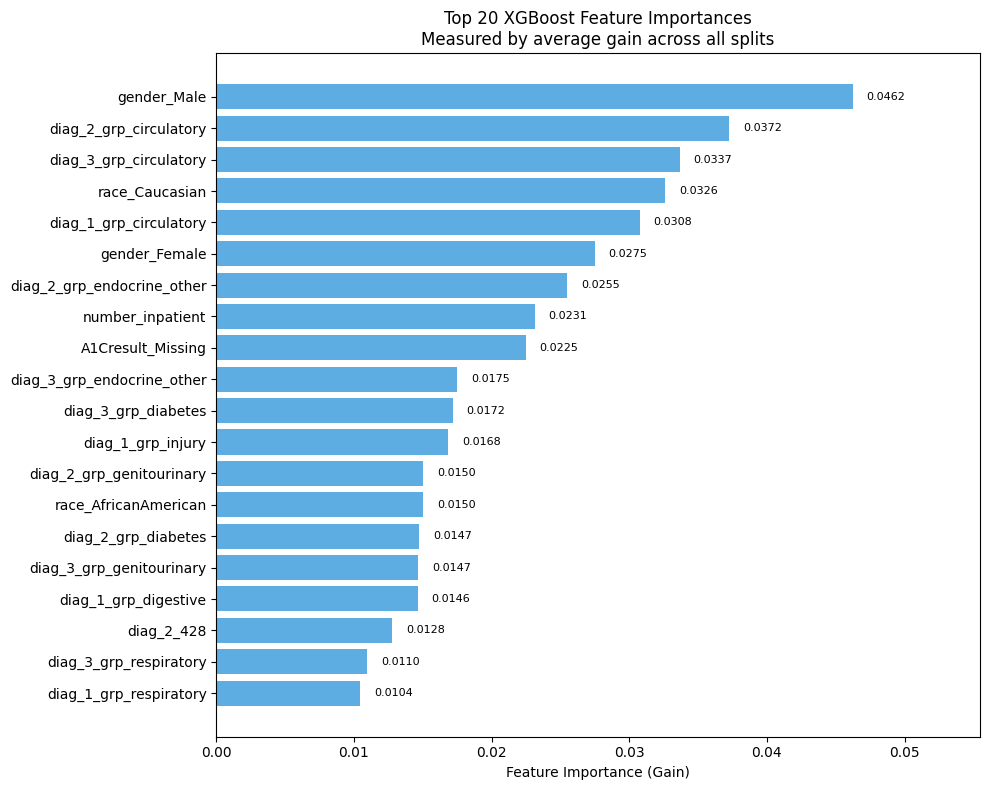

/tmp/ipykernel_1546/1701952880.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


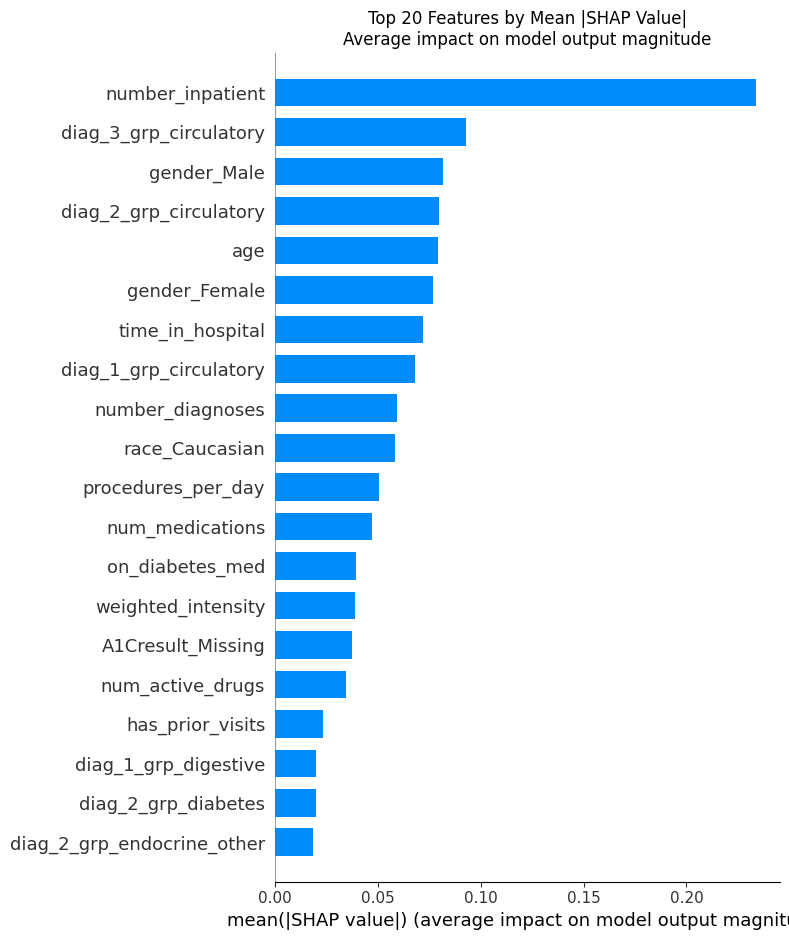

/tmp/ipykernel_1546/1701952880.py:55: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


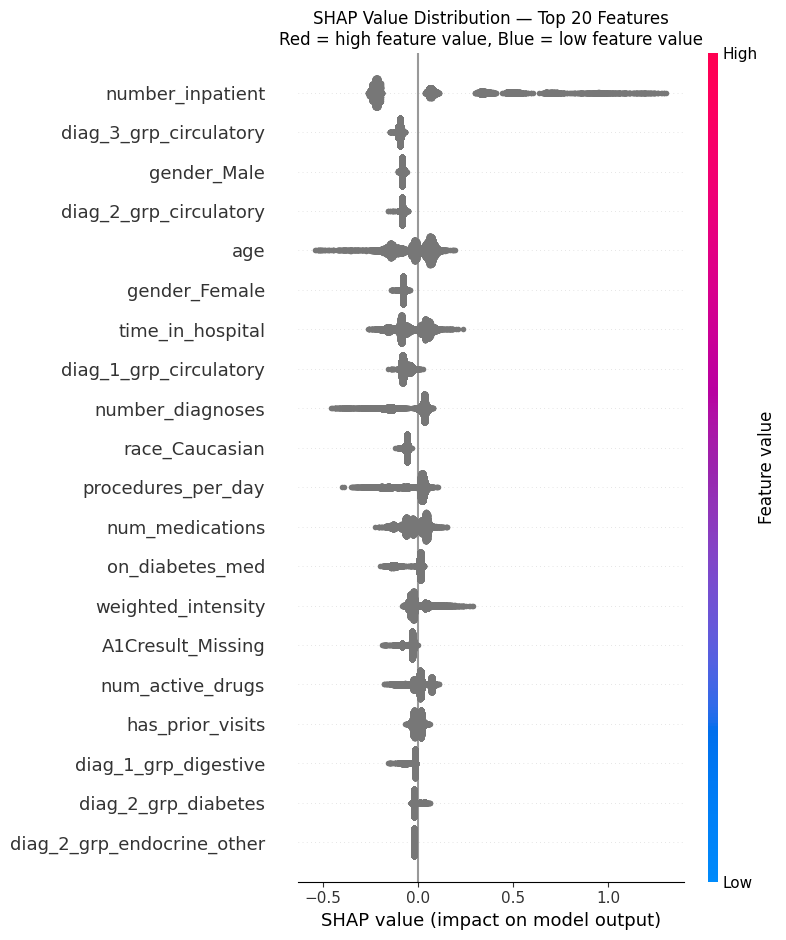

=== Top 10 Features by SHAP Importance ===

Rank  Feature                              Mean |SHAP| Direction
---------------------------------------------------------------------------
1     number_inpatient                          0.2338  ↓ decreases readmission risk
2     diag_3_grp_circulatory                    0.0926  ↓ decreases readmission risk
3     gender_Male                               0.0815  ↓ decreases readmission risk
4     diag_2_grp_circulatory                    0.0798  ↓ decreases readmission risk
5     age                                       0.0792  ↓ decreases readmission risk
6     gender_Female                             0.0767  ↓ decreases readmission risk
7     time_in_hospital                          0.0719  ↓ decreases readmission risk
8     diag_1_grp_circulatory                    0.0680  ↓ decreases readmission risk
9     number_diagnoses                          0.0595  ↓ decreases readmission risk
10    race_Caucasian                            0.

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── 1. Get feature names from fitted preprocessor ─────────────────
feature_names = [
    f.split("__")[-1]
    for f in xgb_pipeline["preprocess"].get_feature_names_out()
]

# ── 2. XGBoost Built-in Feature Importance ────────────────────────
imp_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": xgb_pipeline["model"].feature_importances_
}).sort_values("importance", ascending=True).tail(20)  # top 20

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp_df["feature"], imp_df["importance"],
               color="#3498db", alpha=0.8)
for bar, val in zip(bars, imp_df["importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=8)
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("Top 20 XGBoost Feature Importances\n"
             "Measured by average gain across all splits")
ax.set_xlim(0, imp_df["importance"].max() * 1.2)
plt.tight_layout()
plt.show()

# ── 3. SHAP Values ────────────────────────────────────────────────
# Transform test set through preprocessor only (not SMOTE)
X_test_transformed = xgb_pipeline["preprocess"].transform(X_test)

explainer   = shap.TreeExplainer(xgb_pipeline["model"])
shap_values = explainer.shap_values(X_test_transformed)

# ── 4. SHAP Summary Plot (Bar) — mean absolute impact ─────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Features by Mean |SHAP Value|\n"
          "Average impact on model output magnitude")
plt.tight_layout()
plt.show()

# ── 5. SHAP Summary Plot (Dot) — direction + magnitude ────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Value Distribution — Top 20 Features\n"
          "Red = high feature value, Blue = low feature value")
plt.tight_layout()
plt.show()

# ── 6. Clinical Interpretation Table ──────────────────────────────
shap_importance = pd.DataFrame({
    "feature":          feature_names,
    "mean_abs_shap":    np.abs(shap_values).mean(axis=0),
    "mean_shap":        shap_values.mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(10).reset_index(drop=True)

shap_importance["direction"] = shap_importance["mean_shap"].apply(
    lambda x: "↑ increases readmission risk" if x > 0 else "↓ decreases readmission risk"
)

print("=== Top 10 Features by SHAP Importance ===\n")
print(f"{'Rank':<5} {'Feature':<35} {'Mean |SHAP|':>12} {'Direction'}")
print("-" * 75)
for i, row in shap_importance.iterrows():
    print(f"{i+1:<5} {row['feature']:<35} {row['mean_abs_shap']:>12.4f}  {row['direction']}")